<h1 style='text-align:center; font-weight:bold; color:orange'>Understanding User Preferences: Insights from Website Survey Data Using a 10-Point Likert Scale</h1>

## **1 Scenario**
- The dataset was obtained from [Faisal et al (2017)](https://doi.org/10.1109/THMS.2016.2620901) via [Hayri](https://www.kaggle.com/datasets/hayriyigit/website-satisfaction-survey) on Kaggle.
- Intended for simple data analysis. It does not involve any inferential statistical test and predictive modeling technique. This analysis only covers primarily data visualization for 10-point Likert scale.

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
import pandas as pd
import seaborn as sns
plt.style.use('ggplot')

## **2 Data Preparation**

In [2]:
# load data
df = pd.read_csv('../data/survey.csv')

# check snippet of data
df.iloc[0:6, 0:15].style.set_caption('Website Satisfaction Survey Data')

,user_id,language,platform,gender,age,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10
0,080c468b-27c0-455c-aa63-b8f807f2e3d7,en,Desktop,male,34,9,7,6,6,7,7,6,6,5,5
1,0b0379c7-04db-4c85-84bd-a2bd55329e29,en,Mobile,female,19,10,10,10,9,10,10,10,10,9,10
2,0e623280-b28b-4d4a-8eea-0732f09ed497,en,Mobile,female,19,10,10,10,10,10,10,10,10,10,10
3,045dc0f3-a730-4d03-a615-f51814e5b04f,en,Mobile,male,21,5,8,5,5,5,5,5,6,6,8
4,092f2ee7-5281-4a09-9bce-e5523b95b53b,en,nan,female,53,9,10,9,10,9,7,8,5,7,8
5,19c0851c-cbb1-45b5-9e78-884b761802ac,en,Mobile,female,53,10,9,9,9,5,6,8,7,4,5


In [3]:
# create function to inspect df
def inspect_dataframe(df):
    summary = {
        'ColumnName': df.columns.values.tolist(),
        'Nrow': df.shape[0],
        'DataType': df.dtypes.values.tolist(),
        'NAPct': (df.isna().mean() * 100).round(2).tolist(),
        'DuplicatePct': (df.duplicated().sum()/len(df)*100).round(2),
        'UniqueValue': df.nunique().tolist(),
        'Sample': [df[col].unique() for col in df.columns]
    }
    return pd.DataFrame(summary)

In [4]:
# inspect dataframe
print(f'The dataframe contains {df.shape[0]} rows and {df.shape[1]} cols.')
print(f"- {len(df.select_dtypes(include='number').columns)} are numeric cols")
print(f"- {len(df.select_dtypes(include='O').columns)} are object cols")
inspect_dataframe(df)

The dataframe contains 73 rows and 31 cols.
- 27 are numeric cols
- 4 are object cols


,ColumnName,Nrow,DataType,NAPct,DuplicatePct,UniqueValue,Sample
0,user_id,73,object,0.00,0.0,73,"[080c468b-27c0-455c-aa63-b8f807f2e3d7, 0b0379c..."
1,language,73,object,0.00,0.0,2,"[en, es]"
2,platform,73,object,10.96,0.0,2,"[Desktop, Mobile, nan]"
3,gender,73,object,0.00,0.0,3,"[male, female, other]"
4,age,73,int64,0.00,0.0,24,"[34, 19, 21, 53, 18, 20, 13, 29, 46, 44, 2, 27..."
5,q1,73,int64,0.00,0.0,9,"[9, 10, 5, 8, 7, 4, 3, 6, 1]"
6,q2,73,int64,0.00,0.0,10,"[7, 10, 8, 9, 5, 4, 6, 3, 2, 1]"
7,q3,73,int64,0.00,0.0,10,"[6, 10, 5, 9, 7, 4, 8, 2, 3, 1]"
8,q4,73,int64,0.00,0.0,9,"[6, 9, 10, 5, 7, 8, 4, 3, 2]"
9,q5,73,int64,0.00,0.0,8,"[7, 10, 5, 9, 6, 8, 4, 2]"


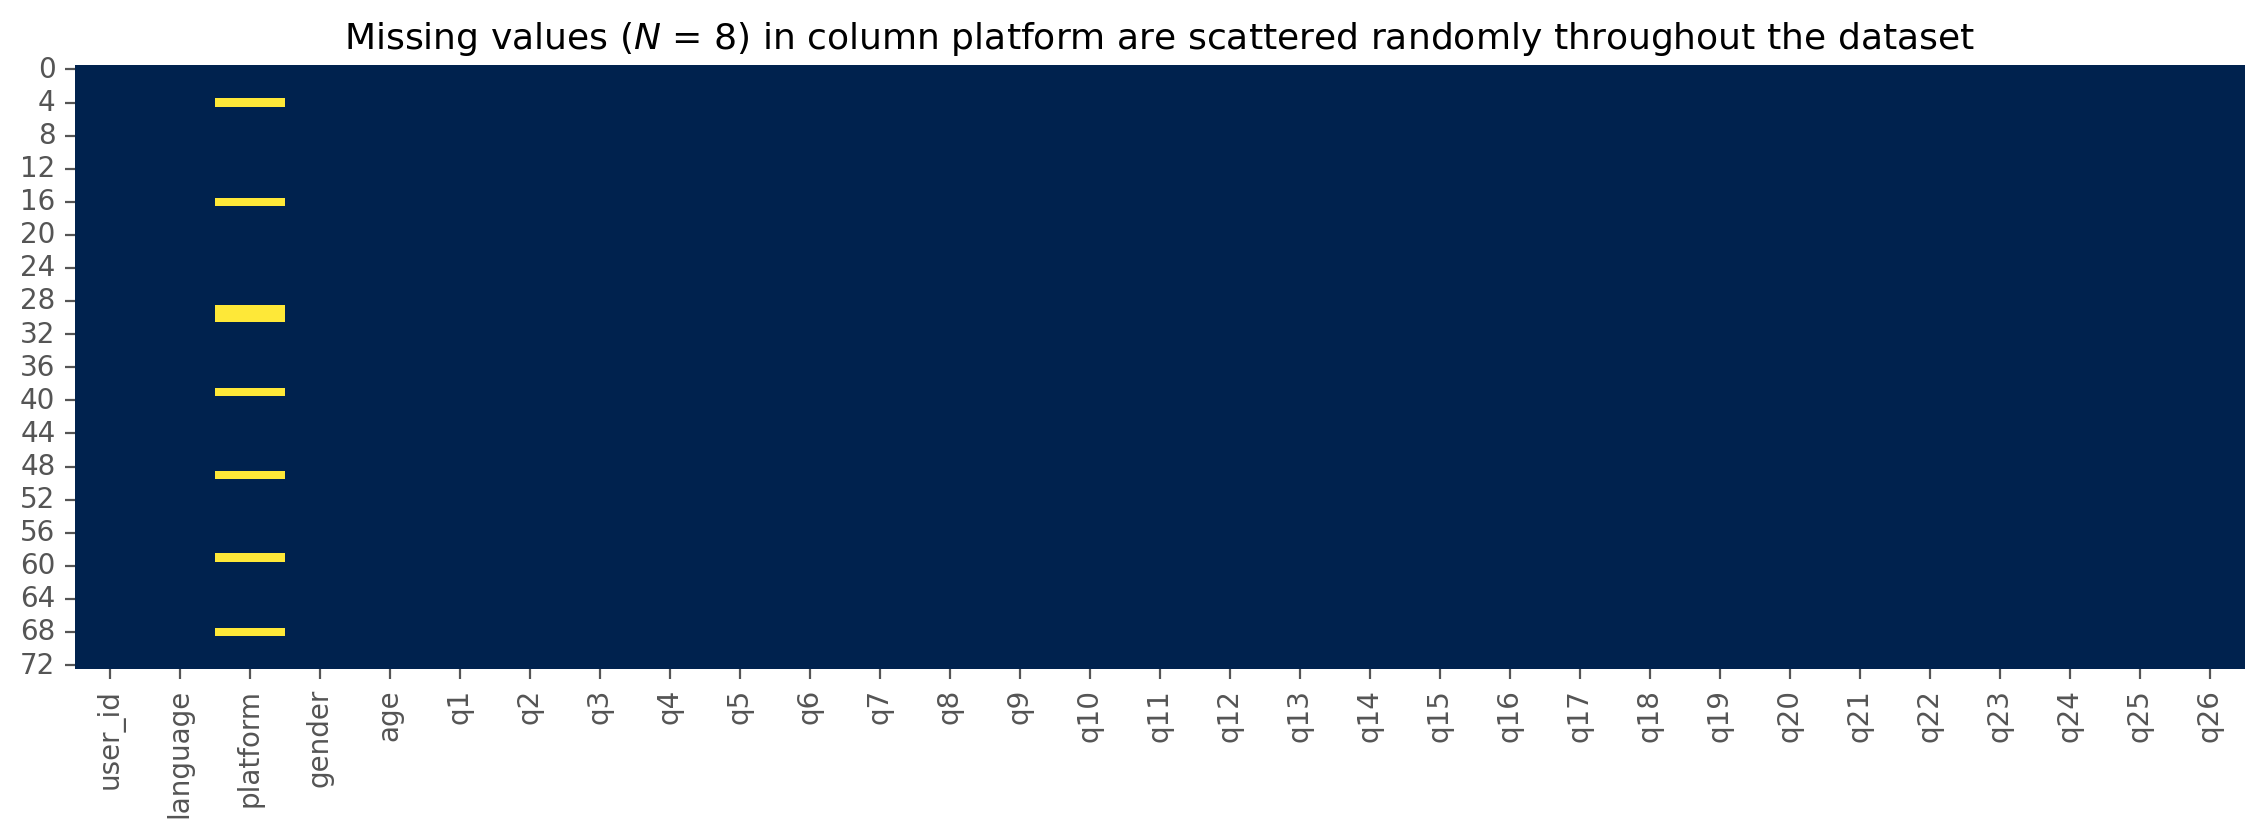

In [5]:
# check columns with missing values
plt.figure(figsize=(14, 4), dpi=200)
n_isna = df['platform'].isna().sum()
sns.heatmap(df.isna(), cmap=mpl.colormaps['cividis'], cbar=False)
plt.title(f'Missing values ($N$ = {n_isna:,}) in column platform are scattered randomly throughout the dataset', fontsize=13)
plt.ylabel(None)
plt.show()

**Note**: Data visualization logic. If there are missing values (`True`), the heatmap plot will indicate stips whose color is different from the surroundings (not missing alias `False`). In the data visualization above, when missing value is True, the heatmap displays yellow color whereas non-missing data will have dark blue color.

In [6]:
# check records with missing values
df[df['platform'].isna()].iloc[:, 0:6]

,user_id,language,platform,gender,age,q1
4,092f2ee7-5281-4a09-9bce-e5523b95b53b,en,NaN,female,53,9
16,10e9b324-156e-4eb5-aec5-04d8a4d7124c,en,NaN,male,46,4
29,25602500-ca31-4404-b155-3e070652c2c0,en,NaN,other,1,7
30,11cbc3a6-1c92-4f10-abe6-27def200d91d,en,NaN,male,25,10
39,40d5e94f-2468-4f73-a0a0-e5a2c0443f06,en,NaN,other,1,6
49,e5eccf62-17fb-4353-b886-e547a9699dd4,en,NaN,male,45,8
59,ba4eba66-ab7c-4704-84e8-4218f019f196,en,NaN,male,23,10
68,cb71d11a-4e8d-4ab8-80be-ac1f46f5b2d1,en,NaN,male,1,9


In [7]:
# perform imputation
df.loc[:, 'platform'] = df['platform'].fillna('Unknown')
print(f'Total missing values (after imputation): {df.isna().sum().sum()}')

Total missing values (after imputation): 0


## **3 Exploratory Data Analysis**

### **3.1 Demography of Respondents**

In [8]:
# prepare data
platform_df = (df['platform'].value_counts(normalize=True)*100).reset_index(name='proportion').round(2)

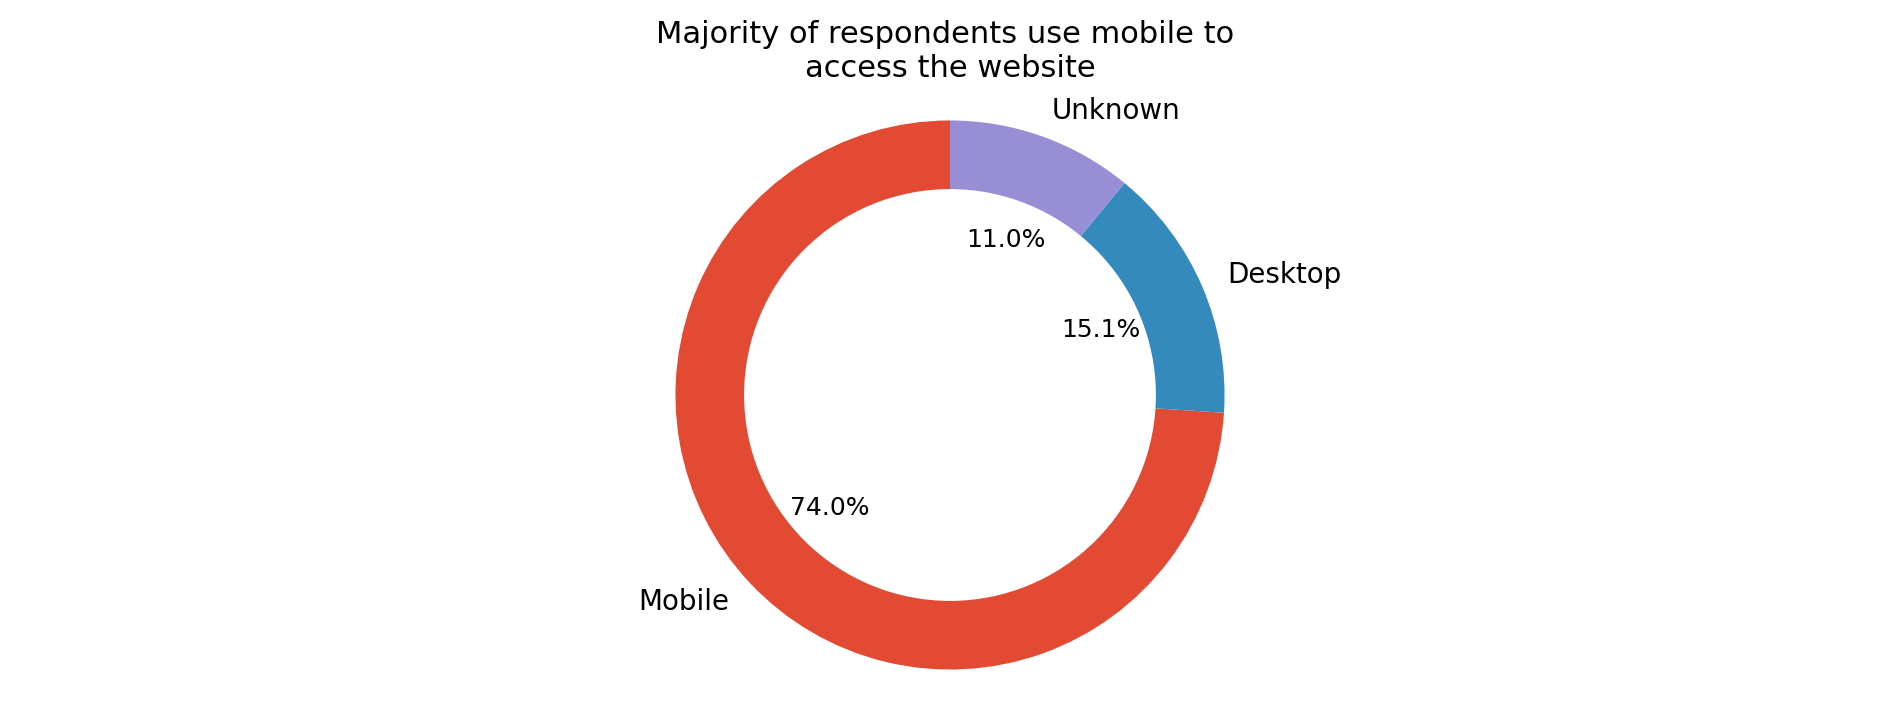

In [9]:
fig, ax = plt.subplots(figsize=(12, 4), dpi=200)
wedges, texts, autotexts = ax.pie(platform_df['proportion'], 
                                  labels=platform_df['index'], 
                                  autopct='%1.1f%%', startangle=90)
# set the font size 
for autotext in autotexts:
    autotext.set_fontsize(9)  

# add a circle to the center
centre_circle = plt.Circle((0, 0), 0.75, fc='white')
fig.gca().add_artist(centre_circle)
ax.axis('equal')  
plt.title("Majority of respondents use mobile to \naccess the website", size=11)
plt.show()

In [10]:
# prepare data
language_df = (df['language'].value_counts(normalize=True)*100).reset_index(name='proportion').round(2)

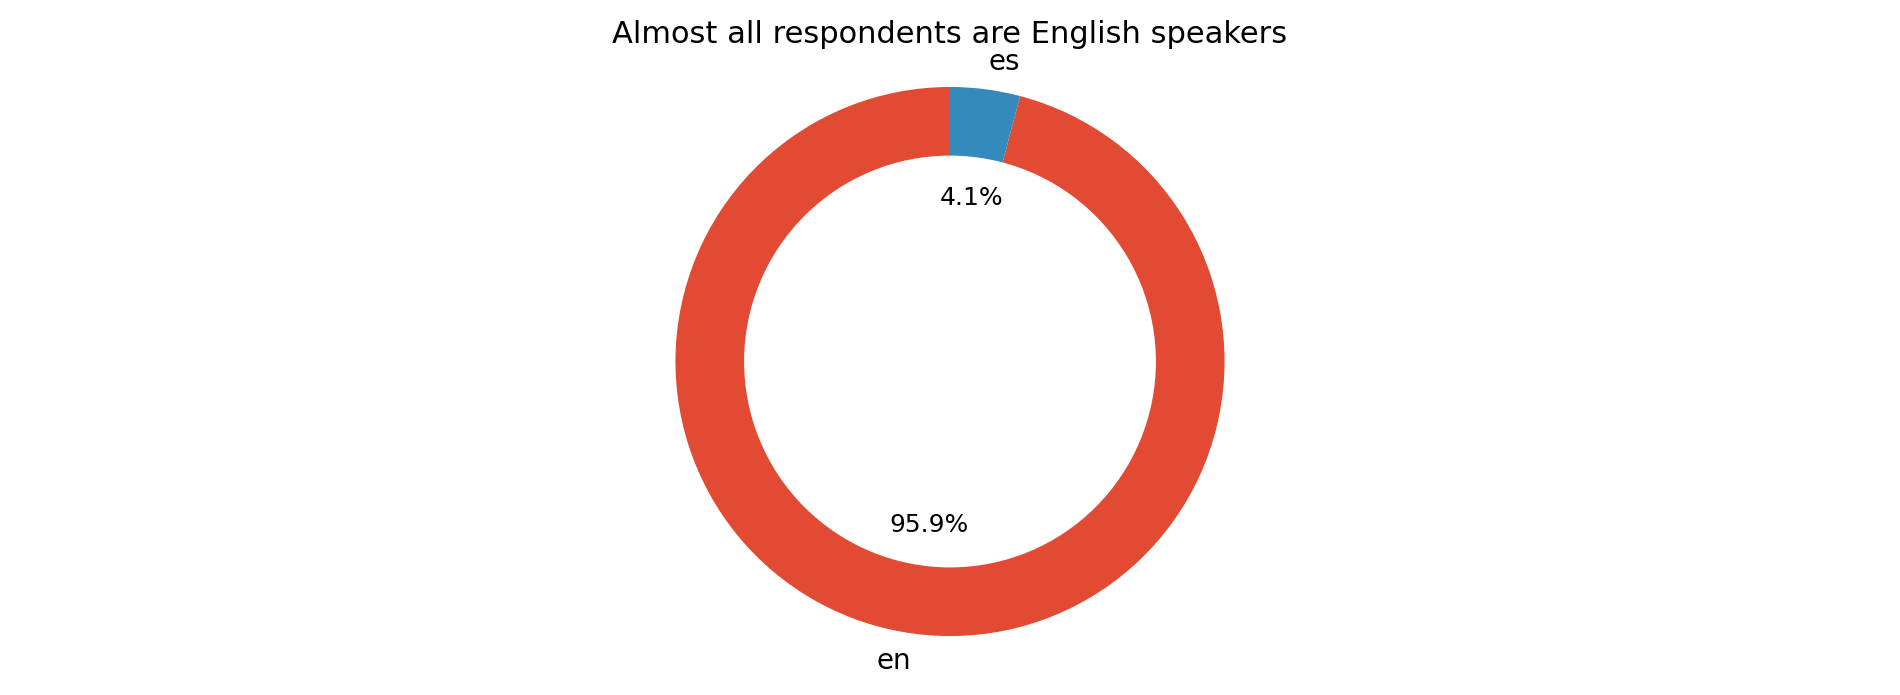

In [11]:
fig, ax = plt.subplots(figsize=(12, 4), dpi=200)
wedges, texts, autotexts = ax.pie(language_df['proportion'], 
                                  labels=language_df['index'], 
                                  autopct='%1.1f%%', startangle=90)
# set the font size 
for autotext in autotexts:
    autotext.set_fontsize(9)  

# add a circle to the center
centre_circle = plt.Circle((0, 0), 0.75, fc='white')
fig.gca().add_artist(centre_circle)
ax.axis('equal')  
plt.title("Almost all respondents are English speakers", size=11)
plt.show()

In [12]:
# prepare data
gender_df = (df['gender'].value_counts(normalize=True)*100).reset_index(name='proportion').round(2)

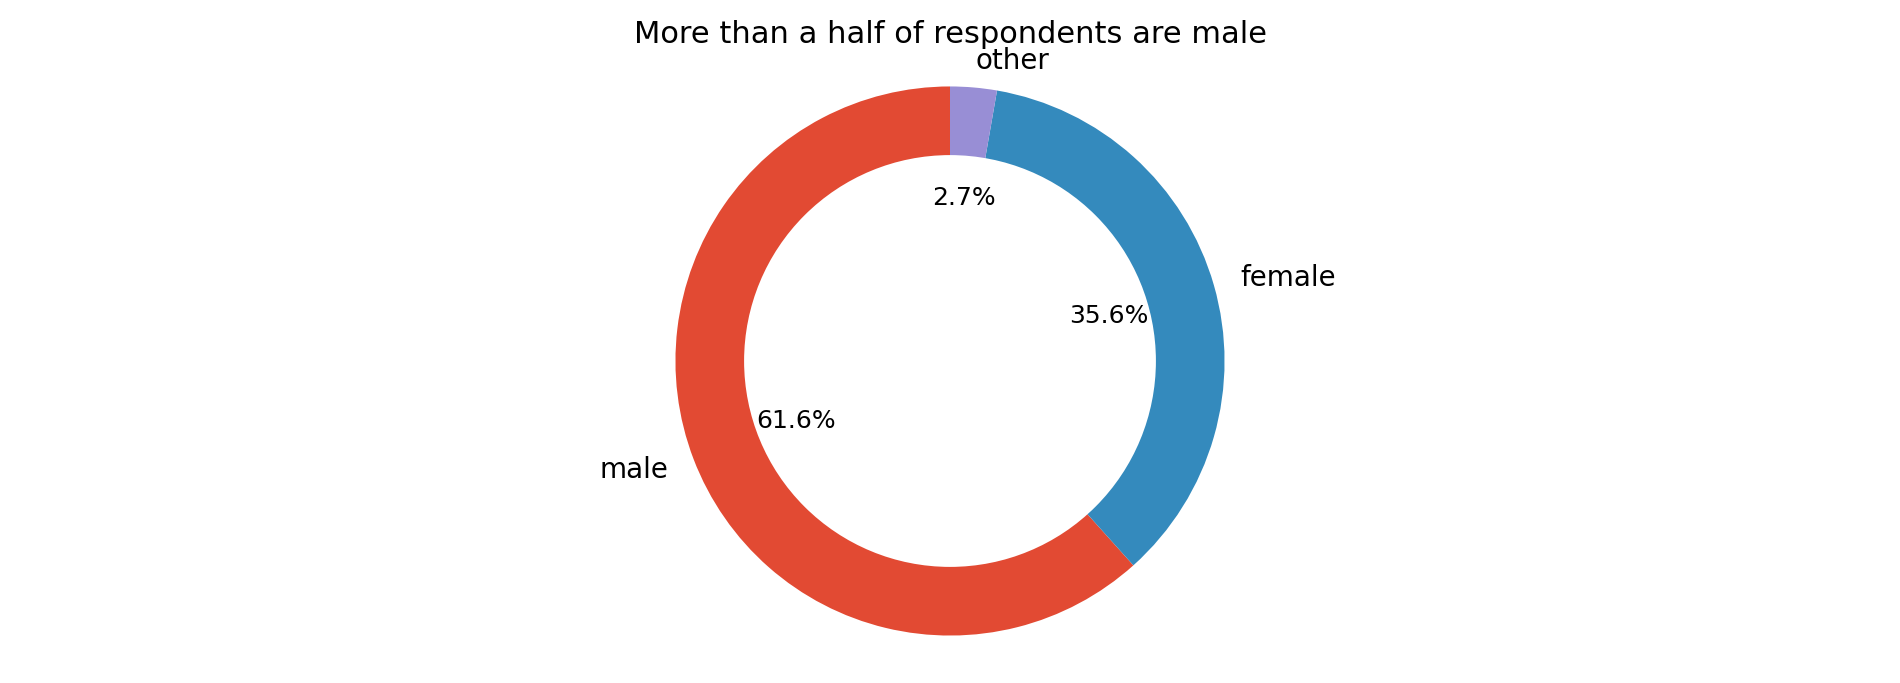

In [13]:
fig, ax = plt.subplots(figsize=(12, 4), dpi=200)
wedges, texts, autotexts = ax.pie(gender_df['proportion'], 
                                  labels=gender_df['index'], 
                                  autopct='%1.1f%%', startangle=90)
# set the font size 
for autotext in autotexts:
    autotext.set_fontsize(9)  

# add a circle to the center
centre_circle = plt.Circle((0, 0), 0.75, fc='white')
fig.gca().add_artist(centre_circle)
ax.axis('equal')  
plt.title("More than a half of respondents are male", size=11)
plt.show()

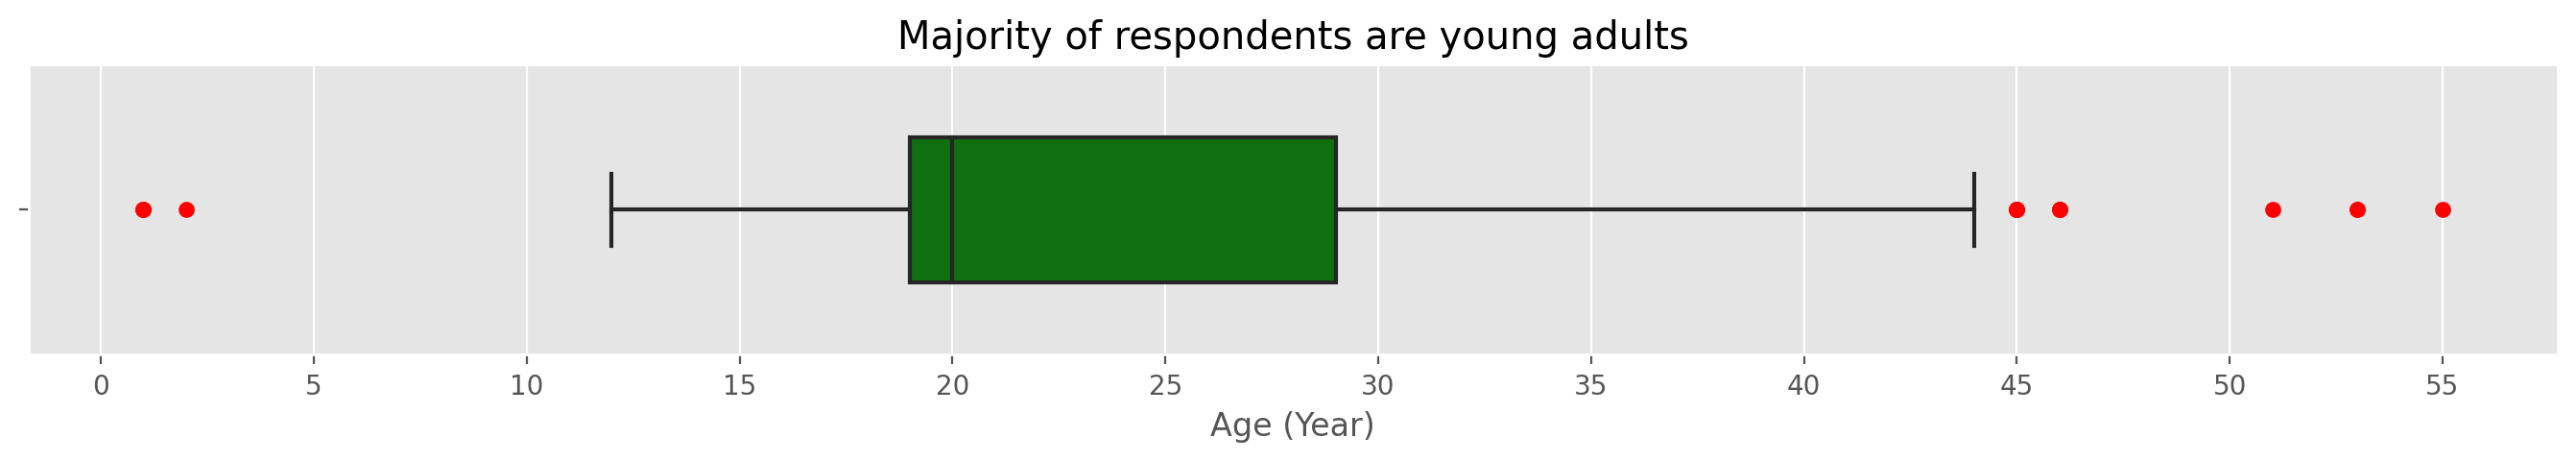

In [14]:
# create boxplot
plt.figure(figsize=(17, 2), dpi=200)
sns.boxplot(x=df['age'], color='green', width=0.5, 
            flierprops=dict(marker='.', markerfacecolor='red', 
                            markeredgecolor='red', alpha=1, 
                            markersize=10))

plt.title('Majority of respondents are young adults')
plt.xlabel('Age (Year)')
plt.xticks(range(0, 60, 5))
plt.show()

In [15]:
# replace values < 12
df.loc[df['age'] < 12, 'age'] = 12

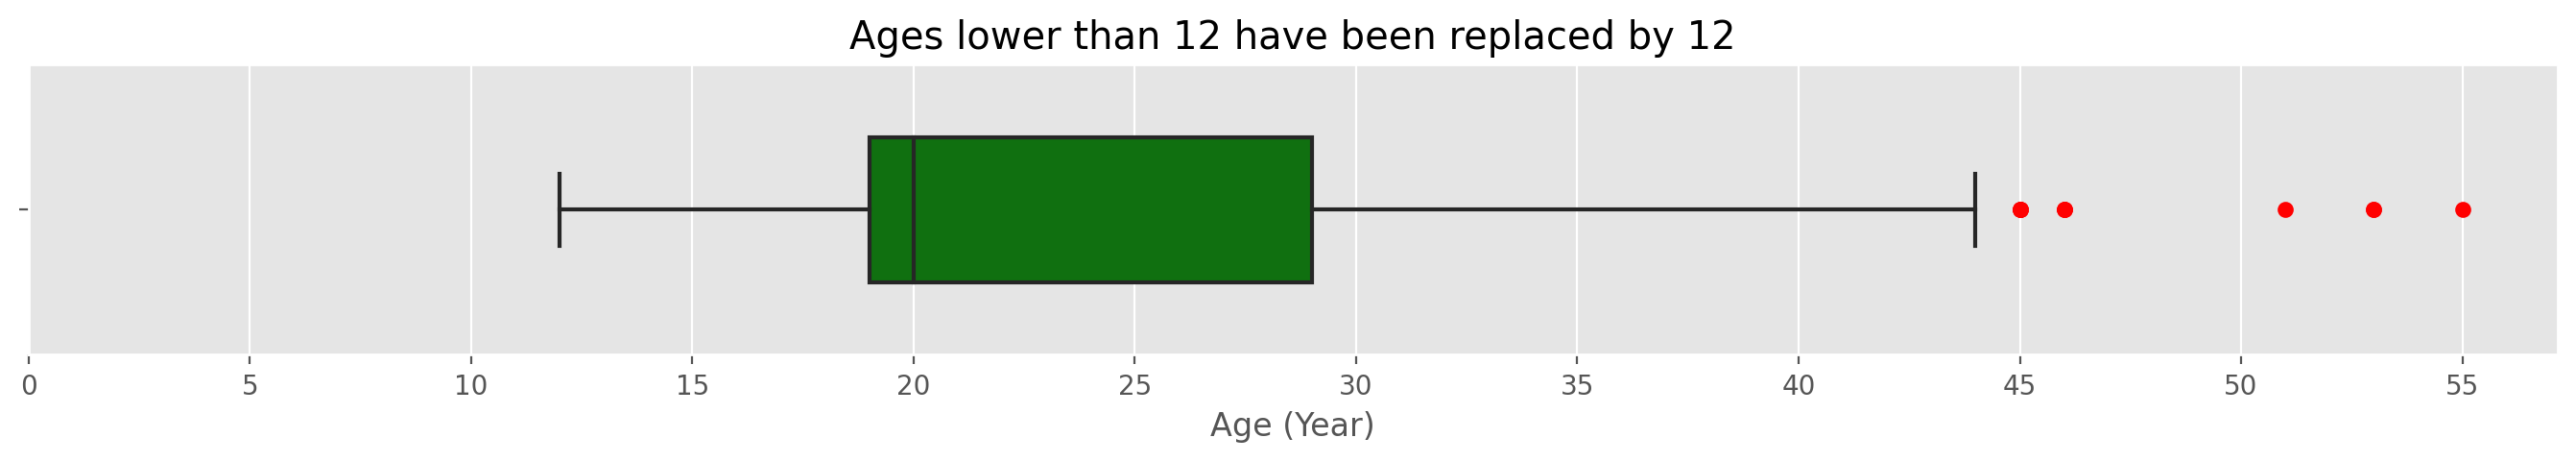

In [16]:
plt.figure(figsize=(17, 2), dpi=200)
sns.boxplot(x=df['age'], color='green', width=0.5, 
            flierprops=dict(marker='.', markerfacecolor='red', 
                            markeredgecolor='red', alpha=1, 
                            markersize=10))

plt.title('Ages lower than 12 have been replaced by 12')
plt.xlabel('Age (Year)')
plt.xticks(range(0, 60, 5))
plt.show()

In [17]:
# prepare data
cat_df = pd.crosstab(df['gender'], [df['platform'], df['language']], normalize=True) * 100

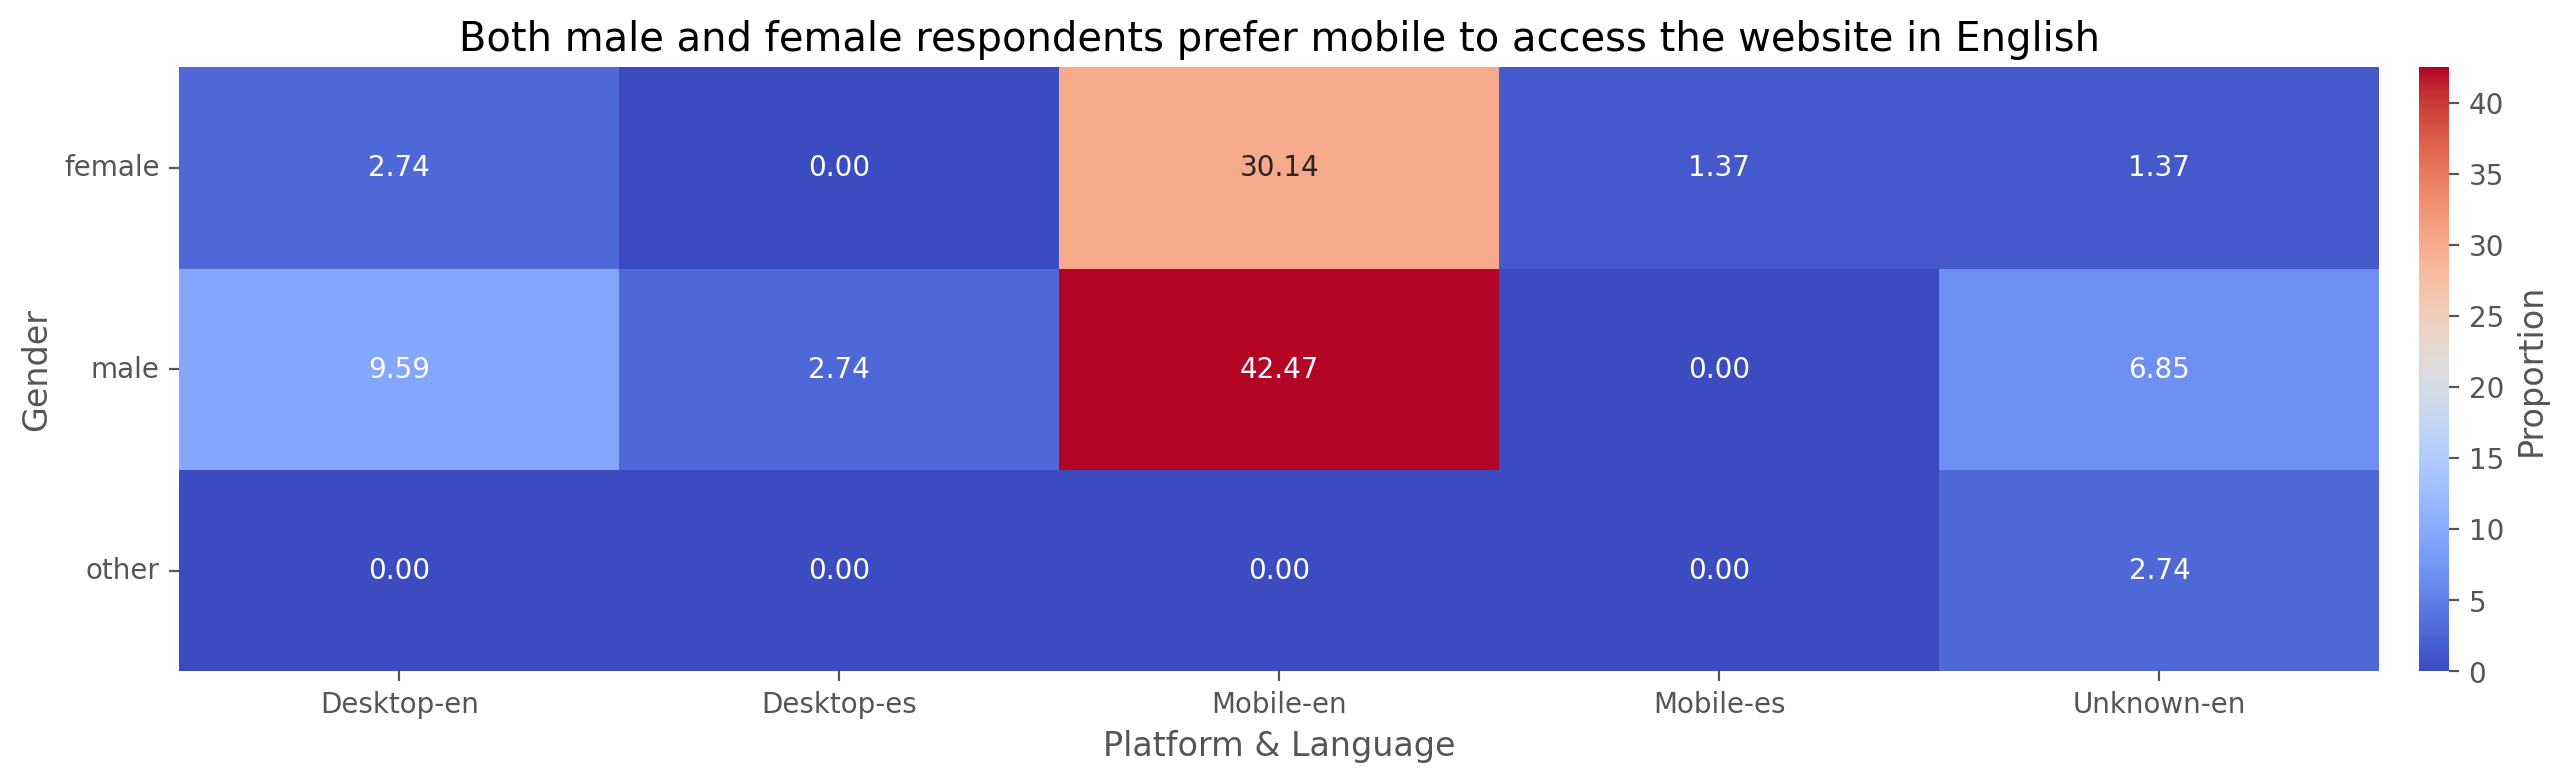

In [79]:
# make heatmap
plt.figure(figsize=(17,4), dpi=200)
sns.heatmap(cat_df, annot=True, cmap='coolwarm', fmt='.2f', cbar_kws={'label':'Proportion', 'pad': 0.015})
plt.title('Both male and female respondents prefer mobile to access the website in English')
plt.xlabel('Platform & Language')
plt.ylabel('Gender')
plt.yticks(rotation=0)
plt.show()

**Note**
- The majority of respondents, both male and female, prefer accessing the website via mobile devices, particularly in English. This suggests that optimizing the mobile experience should be a priority.
- There is a notable preference for using the website in English across all platforms, with very few respondents using the Spanish version. This indicates a potential area for growth in the Spanish-speaking market.

In [19]:
# subset dataset
q_columns = df.loc[:, 'q1':'q26']
q_columns.iloc[:5, :15]

,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10,q11,q12,q13,q14,q15
0,9,7,6,6,7,7,6,6,5,5,5,3,6,4,5
1,10,10,10,9,10,10,10,10,9,10,10,10,10,10,10
2,10,10,10,10,10,10,10,10,10,10,10,10,6,9,7
3,5,8,5,5,5,5,5,6,6,8,7,8,10,9,5
4,9,10,9,10,9,7,8,5,7,8,7,8,10,9,8


In [20]:
# get descriptive statistics
q_columns.describe().round(2).style.background_gradient(cmap='YlOrRd', axis=1).format("{:.2f}")

,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10,q11,q12,q13,q14,q15,q16,q17,q18,q19,q20,q21,q22,q23,q24,q25,q26
count,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00,73.00
mean,8.01,7.86,7.82,7.41,7.51,7.64,7.63,7.60,7.07,6.44,7.05,6.86,7.53,7.68,7.58,7.04,8.07,7.45,7.47,7.41,7.59,7.81,7.56,7.48,7.56,7.33
std,2.20,1.95,2.23,2.04,1.76,2.00,1.96,1.91,2.28,2.32,2.07,2.39,1.95,1.86,2.15,2.14,2.07,2.04,2.30,2.18,2.41,2.19,2.47,2.30,2.28,2.33
min,1.00,1.00,1.00,2.00,2.00,2.00,1.00,2.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,7.00,7.00,7.00,6.00,7.00,7.00,7.00,7.00,6.00,5.00,6.00,5.00,6.00,7.00,7.00,6.00,7.00,6.00,6.00,6.00,7.00,7.00,6.00,7.00,7.00,6.00
50%,9.00,8.00,9.00,8.00,8.00,8.00,8.00,8.00,7.00,6.00,7.00,7.00,8.00,8.00,8.00,7.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00
75%,10.00,9.00,9.00,9.00,9.00,9.00,9.00,9.00,9.00,8.00,8.00,9.00,9.00,9.00,9.00,9.00,10.00,9.00,9.00,9.00,9.00,9.00,10.00,9.00,9.00,9.00
max,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00


### **3.2 General Overview of the Satisfaction Survey**

In [21]:
# function to categorize responses
def categorize_response(score):
    if score <= 2:
        return 'Strongly Disagree'
    elif score <= 4:
        return 'Disagree'
    elif score <= 6:
        return 'Neutral'
    elif score <= 8:
        return 'Agree'
    else:
        return 'Strongly Agree'

# apply function
categorical_df = q_columns.applymap(categorize_response)

In [22]:
# calculate percentage of each category for each question
percentages = categorical_df.apply(lambda x: x.value_counts(normalize=True)
                                   .reindex(['Strongly Disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly Agree'],
                                            fill_value=0) * 100)
# transpose df
percentages = percentages.T

# rename index
percentages.index = [f'Q{i+1}' for i in range(len(percentages.index))]

# show in ascending order
percentages = percentages.iloc[::-1]
percentages.loc["Q5":"Q1", :]

,Strongly Disagree,Disagree,Neutral,Agree,Strongly Agree
Q5,2.739726,1.369863,20.547945,47.945205,27.397260
Q4,1.369863,9.589041,21.917808,28.767123,38.356164
Q3,4.109589,5.479452,15.068493,23.287671,52.054795
Q2,2.739726,4.109589,12.328767,36.986301,43.835616
Q1,4.109589,4.109589,9.589041,30.136986,52.054795


In [23]:
fig, ax = plt.subplots(figsize=(17, len(percentages.index) * 1.3), dpi=500)
colors = ['#ce5258', '#f99d9b', '#d5d4d4', '#a4cbea', '#49779f']

# visualize main plot
percentages.plot(kind='barh', stacked=True, color=colors, ax=ax)
ax.set_title('Overall, users love the website', y=1.015, weight='bold', size=28)
ax.set_xlabel('Percentage', size=14, labelpad=-3)
ax.set_ylabel(None)
ax.set_xticks([])
ax.set_xlim(0, 100)                                                     # keep limits for percentage scale
ax.set_yticklabels(percentages.index, position=(-0.001, 0), size=14)    # move y-ticks slightly to the left

# add data labels
for i in range(len(percentages)):
    cumulative = 0
    for j in range(len(colors)):
        cumulative += percentages.iloc[i, j]
        # change color for Strongly Disagree and Strongly Agree
        label_color = 'white' if j == 0 or j == 4 else 'black'  
        ax.text(cumulative - percentages.iloc[i, j]/2, i,
                f"{percentages.iloc[i, j]:.1f}",
                ha='center', va='center', color=label_color, size=12)

# create custom legend
legend_labels = ['Strongly Disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly Agree']
handles = [Patch(color=colors[i], label=legend_labels[i]) for i in range(len(legend_labels))]
ax.legend(handles=handles, bbox_to_anchor=(0.5, 1.005), loc='center', 
          ncol=5, facecolor='white', frameon=False, fontsize=14)
ax.yaxis.set_tick_params(which='both', length=0)
ax.grid(None)

# remove background color
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
# plt.tight_layout()
plt.show()

**Note**: The majority of users have positive feelings towards the website, with most items showing a significant proportion of “Love it” and “It’s good” responses. Item Q19 has the lowest percentage of users who “Love it,” indicating it may need attention to enhance user satisfaction.

### **3.3 Satisfaction Survey per UX Component**
#### **3.3.1 Typography**

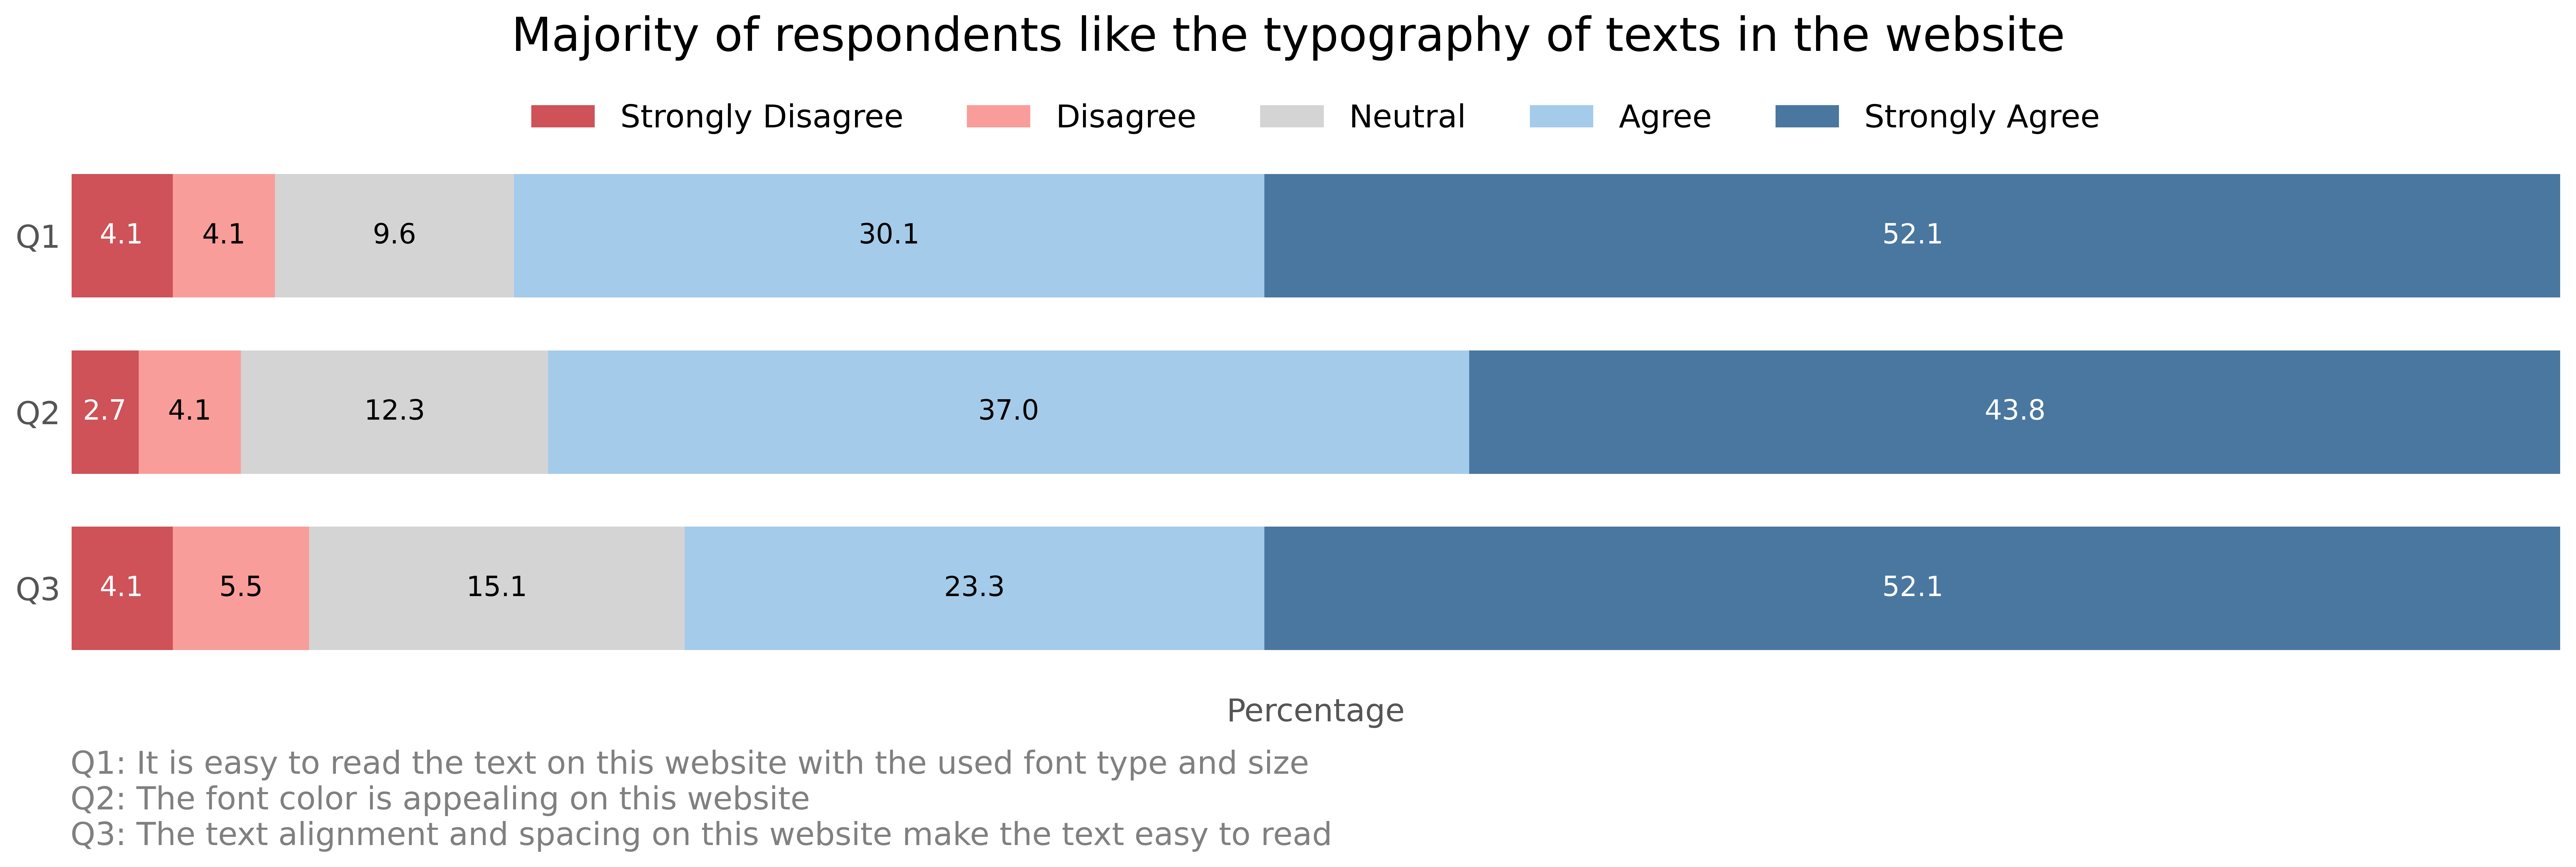

In [78]:
# Select specific questions to visualize
selected_questions = percentages.loc['Q3':'Q1', :]
# selected_questions = selected_questions.iloc[::1]

fig, ax = plt.subplots(figsize=(17, len(selected_questions.index) * 2), dpi=500)
colors = ['#ce5258', '#f99d9b', '#d5d4d4', '#a4cbea', '#49779f']

# visualize main plot
selected_questions.plot(kind='barh', stacked=True, color=colors, ax=ax, width=0.7)

# add main title and subtitle
fig.suptitle('Majority of respondents like the typography of texts in the website', 
             y=0.98, size=22)
ax.set_title('Q1: It is easy to read the text on this website with the used font type and size\n' 
             'Q2: The font color is appealing on this website\n' 
             'Q3: The text alignment and spacing on this website make the text easy to read', 
             fontsize=15, loc='left', y=-0.29, color='grey',  style='normal')

ax.set_xlabel('Percentage', labelpad=-2, size=15)
ax.set_ylabel(None)
ax.set_xticks([])
ax.set_xlim(0, 100)
ax.set_yticklabels(selected_questions.index, position=(-0.001, 0), size=15)

# add data labels
for i in range(len(selected_questions)):
    cumulative = 0
    for j in range(len(colors)):
        cumulative += selected_questions.iloc[i, j]
        label_color = 'white' if j == 0 or j == 4 else 'black'
        ax.text(cumulative - selected_questions.iloc[i, j]/2, i,
                f"{selected_questions.iloc[i, j]:.1f}",
                ha='center', va='center', color=label_color, size=13)

ax.legend(bbox_to_anchor=(0.5, 1.02), loc='center', ncol=5, facecolor='white', 
          frameon=False, fontsize=15)
ax.yaxis.set_tick_params(which='both', length=0)
ax.grid(None)

# remove background color
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
# tighten the layout to reduce spacing
plt.tight_layout()
plt.show()

**Note**: Overall, the stacked bar chart suggests that the website's typography is generally well-received by users. The majority of respondents found the text easy to read, the font color appealing, and the alignment and spacing effective. These positive perceptions contribute to a positive user experience and overall website satisfaction.

#### **3.3.2 Colors** 

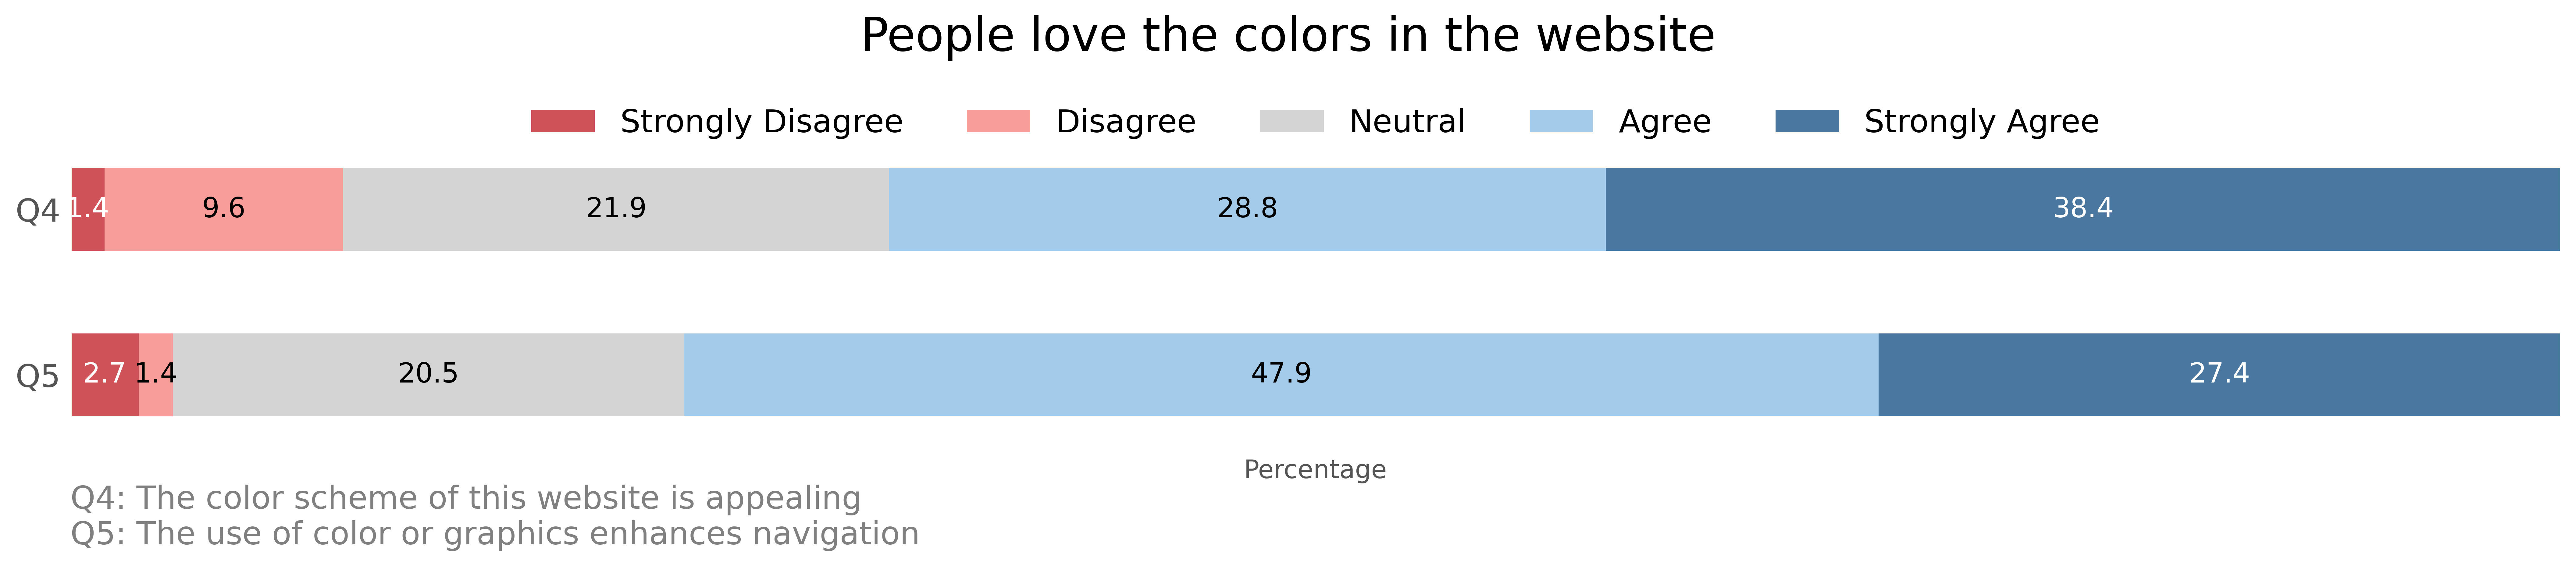

In [42]:
# select specific questions to visualize
selected_questions = percentages.loc['Q5':'Q4', :]

fig, ax = plt.subplots(figsize=(17, len(selected_questions.index) * 2), dpi=500)
colors = ['#ce5258', '#f99d9b', '#d5d4d4', '#a4cbea', '#49779f']

# visualize main plot
selected_questions.plot(kind='barh', stacked=True, color=colors, ax=ax)
# add main title and subtitle
fig.suptitle('People love the colors in the website', y=0.98, size=22, weight='normal')
ax.set_title('Q4: The color scheme of this website is appealing\n' 
             'Q5: The use of color or graphics enhances navigation', 
             fontsize=15, loc='left', y=-0.3, color='grey', style='normal')
ax.set_xlabel('Percentage', labelpad=-3)
ax.set_ylabel(None)
ax.set_xticks([])
ax.set_xlim(0, 100)
ax.set_yticklabels(selected_questions.index, position=(-0.001, 0), size=15)
# add data labels
for i in range(len(selected_questions)):
    cumulative = 0
    for j in range(len(colors)):
        cumulative += selected_questions.iloc[i, j]
        label_color = 'white' if j == 0 or j == 4 else 'black'
        ax.text(cumulative - selected_questions.iloc[i, j]/2, i,
                f"{selected_questions.iloc[i, j]:.1f}",
                ha='center', va='center', color=label_color, size=13)
# setup legend
ax.legend(bbox_to_anchor=(0.5, 1.01), loc='center', ncol=5, facecolor='white', 
          frameon=False, fontsize=15)
ax.yaxis.set_tick_params(which='both', length=0)
ax.grid(None)
# remove background color
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
plt.tight_layout()
plt.show()

**Note**: Overall, users find the website’s color scheme appealing, but there is notable dissatisfaction with how colors or graphics enhance navigation. Many users are neutral or indifferent about both aspects, indicating potential areas for improvement.

#### **3.3.3. Content/information quality**

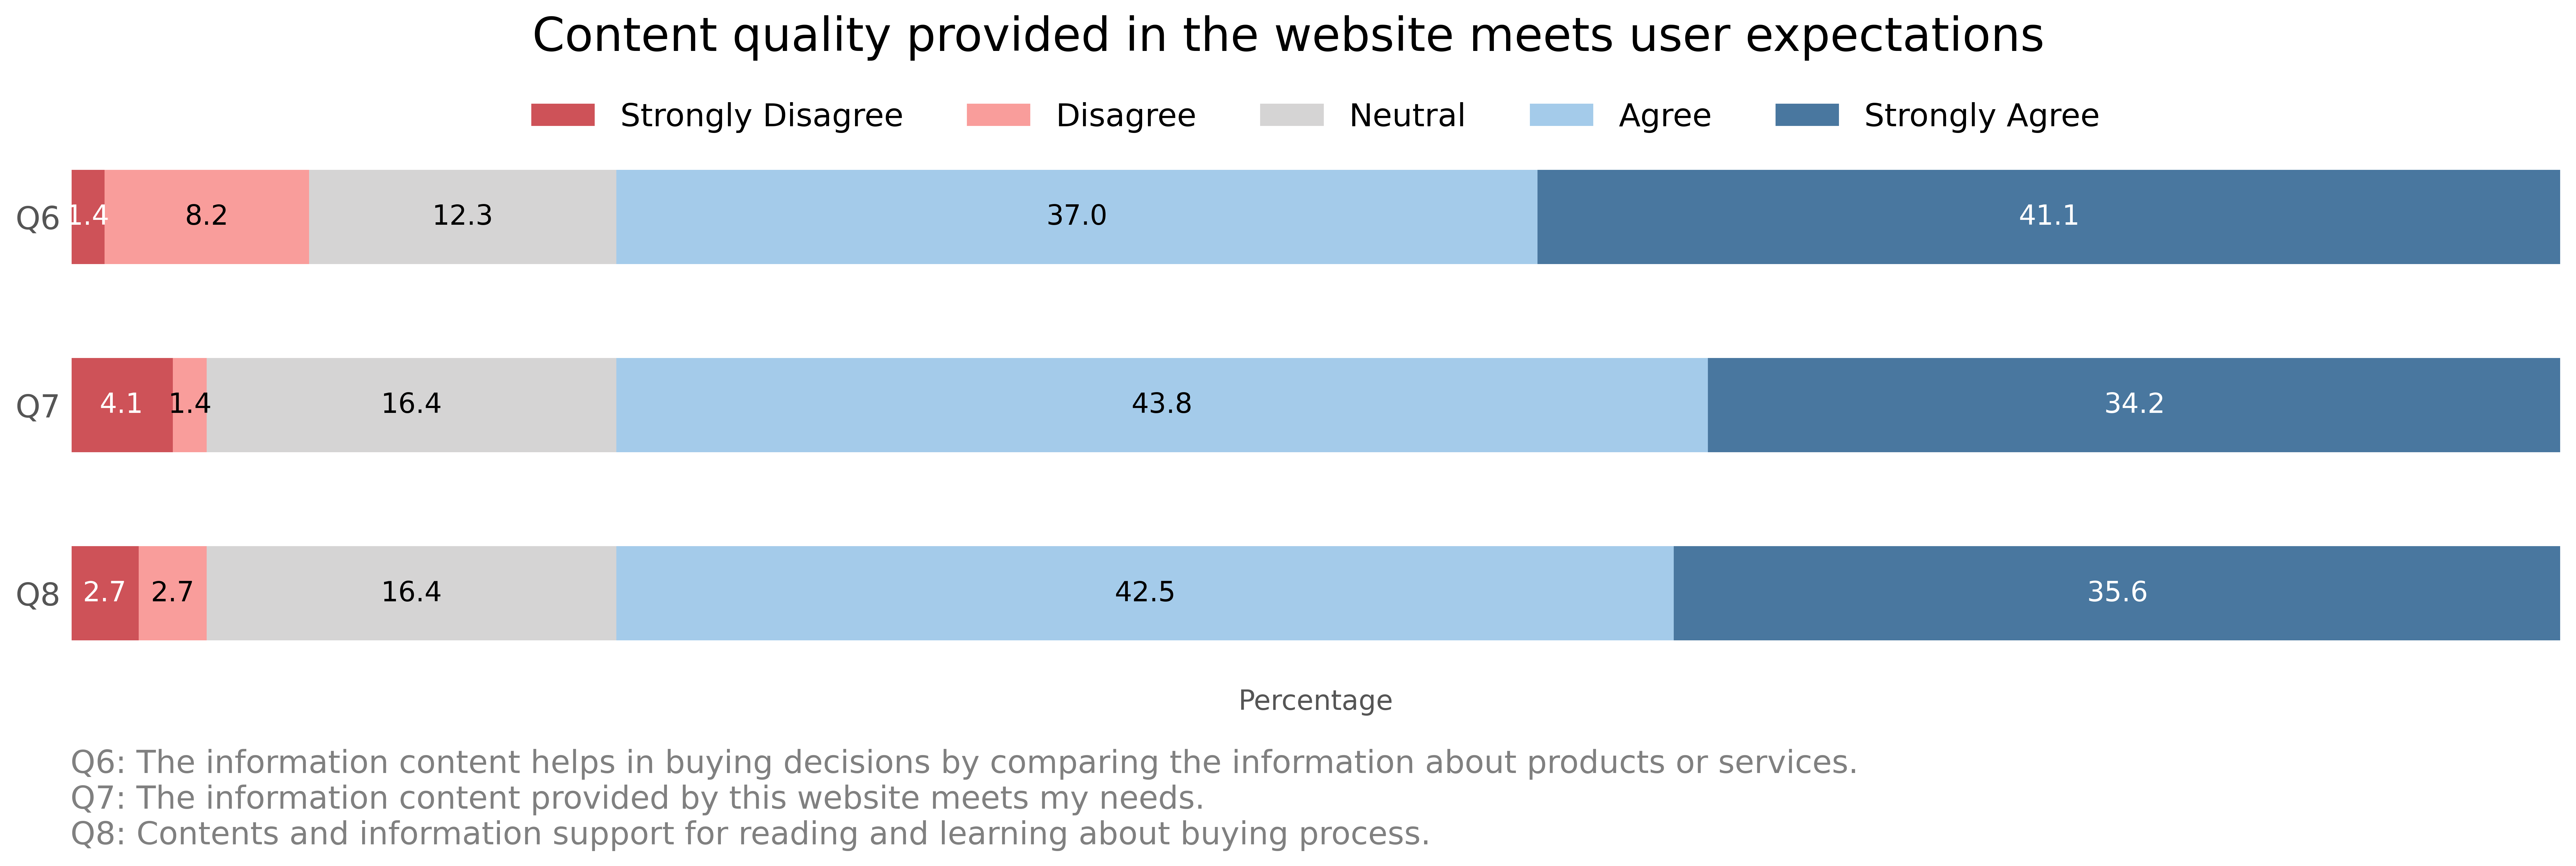

In [74]:
# select specific questions to visualize
selected_questions = percentages.loc['Q8':'Q6', :]

fig, ax = plt.subplots(figsize=(17, len(selected_questions.index) * 2), dpi=500)
colors = ['#ce5258', '#f99d9b', '#d5d4d4', '#a4cbea', '#49779f']

# visualize main plot
selected_questions.plot(kind='barh', stacked=True, color=colors, ax=ax)
# add main title and subtitle
fig.suptitle('Content quality provided in the website meets user expectations', y=0.98, size=22,  weight='normal')
ax.set_title('Q6: The information content helps in buying decisions by comparing the information about products or services.\n' 
             'Q7: The information content provided by this website meets my needs.\n' 
             'Q8: Contents and information support for reading and learning about buying process.', 
             fontsize=15, loc='left', y=-0.3, color='grey', style='normal')
ax.set_xlabel('Percentage', labelpad=-3, size=13)
ax.set_ylabel(None)
ax.set_xticks([])
ax.set_xlim(0, 100)
ax.set_yticklabels(selected_questions.index, position=(-0.001, 0), size=15)
# add data labels
for i in range(len(selected_questions)):
    cumulative = 0
    for j in range(len(colors)):
        cumulative += selected_questions.iloc[i, j]
        label_color = 'white' if j == 0 or j == 4 else 'black'
        ax.text(cumulative - selected_questions.iloc[i, j]/2, i,
                f"{selected_questions.iloc[i, j]:.1f}",
                ha='center', va='center', color=label_color, size=13)
# setup legend
ax.legend(bbox_to_anchor=(0.5, 1.01), loc='center', ncol=5, facecolor='white', 
          frameon=False, fontsize=15)
ax.yaxis.set_tick_params(which='both', length=0)
ax.grid(None)
# remove background color
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
plt.tight_layout()
plt.show()

**Note**: The website’s content effectively aids users in making informed buying decisions and meets their informational needs. However, there is room for improvement in providing content that supports reading and learning about the buying process.

#### **3.3.4 Interactivity**

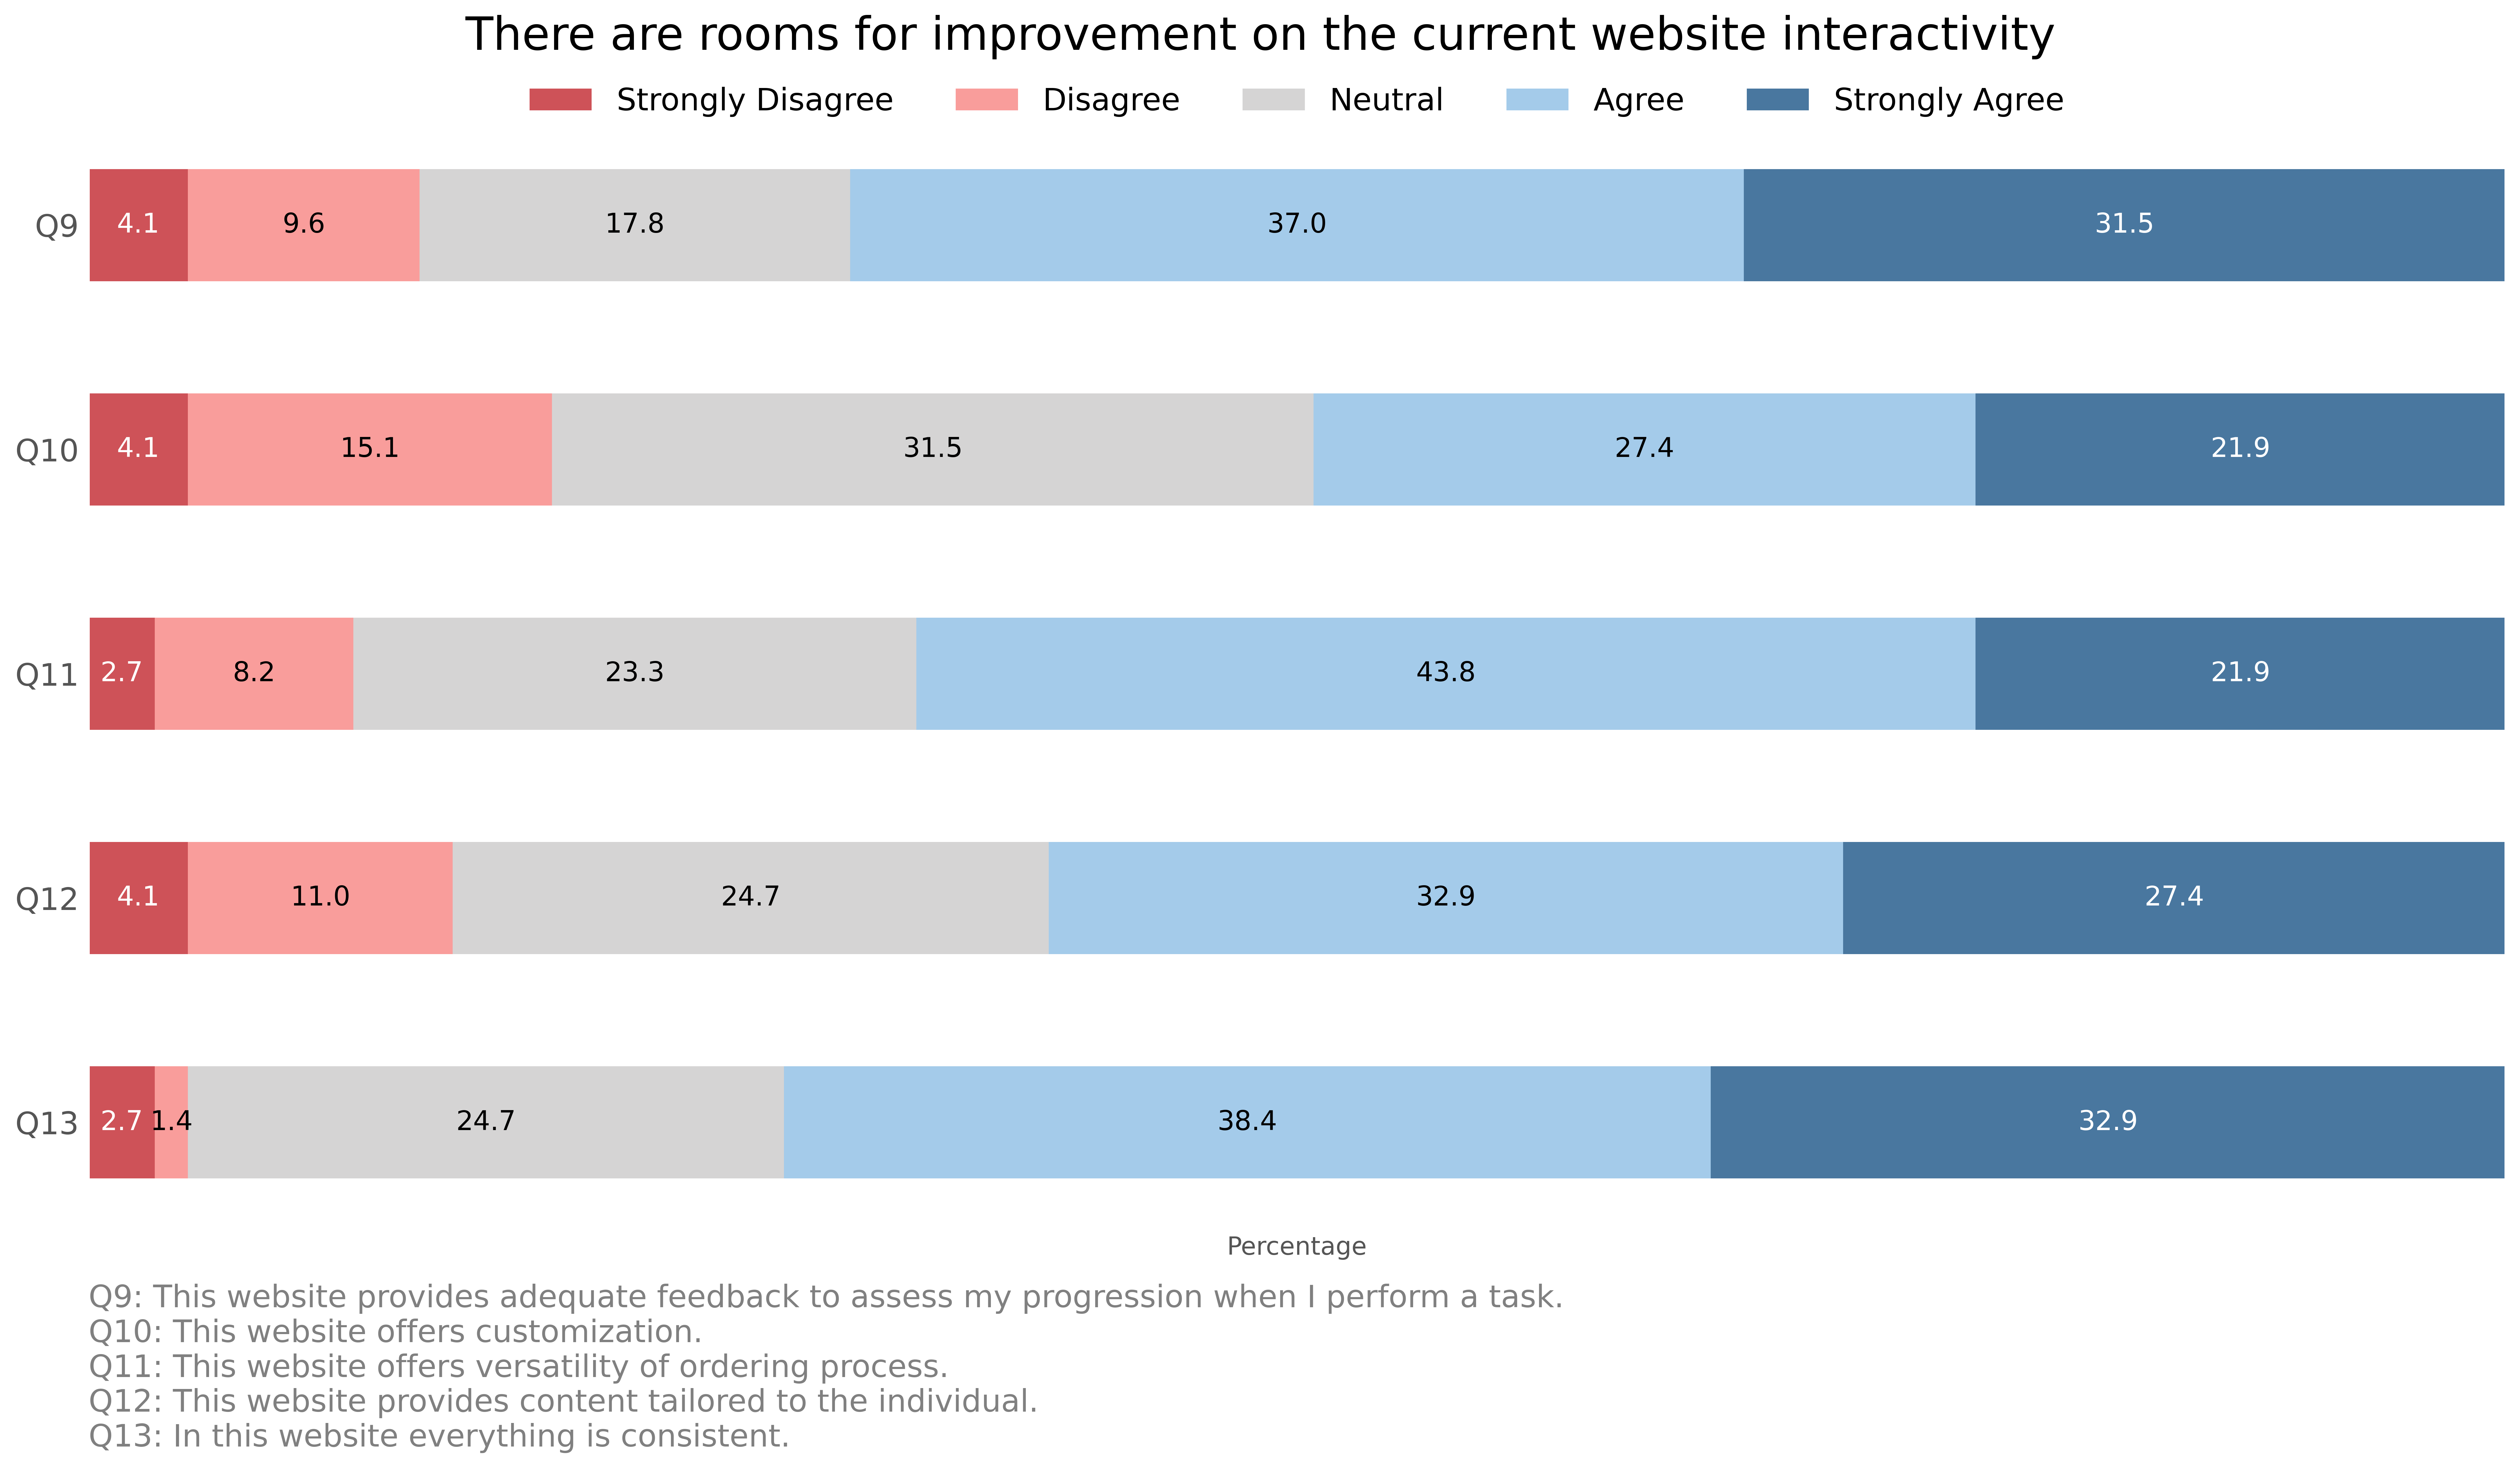

In [50]:
# select specific questions to visualize
selected_questions = percentages.loc['Q13':'Q9', :]

fig, ax = plt.subplots(figsize=(17, len(selected_questions.index) * 2), dpi=500)
colors = ['#ce5258', '#f99d9b', '#d5d4d4', '#a4cbea', '#49779f']

# visualize main plot
selected_questions.plot(kind='barh', stacked=True, color=colors, ax=ax)
# add main title and subtitle
fig.suptitle('There are rooms for improvement on the current website interactivity', y=0.98, size=22, weight='normal')
ax.set_title('Q9: This website provides adequate feedback to assess my progression when I perform a task.\n' 
             'Q10: This website offers customization.\n' 
             'Q11: This website offers versatility of ordering process.\n' 
             'Q12: This website provides content tailored to the individual.\n' 
             'Q13: In this website everything is consistent.', 
             fontsize=15, loc='left', y=-0.2, color='grey',  style='normal')
ax.set_xlabel('Percentage', labelpad=-3)
ax.set_ylabel(None)
ax.set_xticks([])
ax.set_xlim(0, 100)
ax.set_yticklabels(selected_questions.index, position=(-0.001, 0), size=15)
# add data labels
for i in range(len(selected_questions)):
    cumulative = 0
    for j in range(len(colors)):
        cumulative += selected_questions.iloc[i, j]
        label_color = 'white' if j == 0 or j == 4 else 'black'
        ax.text(cumulative - selected_questions.iloc[i, j]/2, i,
                f"{selected_questions.iloc[i, j]:.1f}",
                ha='center', va='center', color=label_color, size=13)
# setup legend
ax.legend(bbox_to_anchor=(0.5, 1.01), loc='center', ncol=5, facecolor='white', 
          frameon=False, fontsize=15)
ax.yaxis.set_tick_params(which='both', length=0)
ax.grid(None)
# remove background color
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
plt.tight_layout()
plt.show()

**Note**: Overall, the website’s interactivity is well-received, with positive feedback on task progression, customization, and consistency. However, there is a notable neutral or negative response regarding the versatility of the ordering process and tailored content, indicating areas for potential improvement.

#### **3.3.5 Navigation**

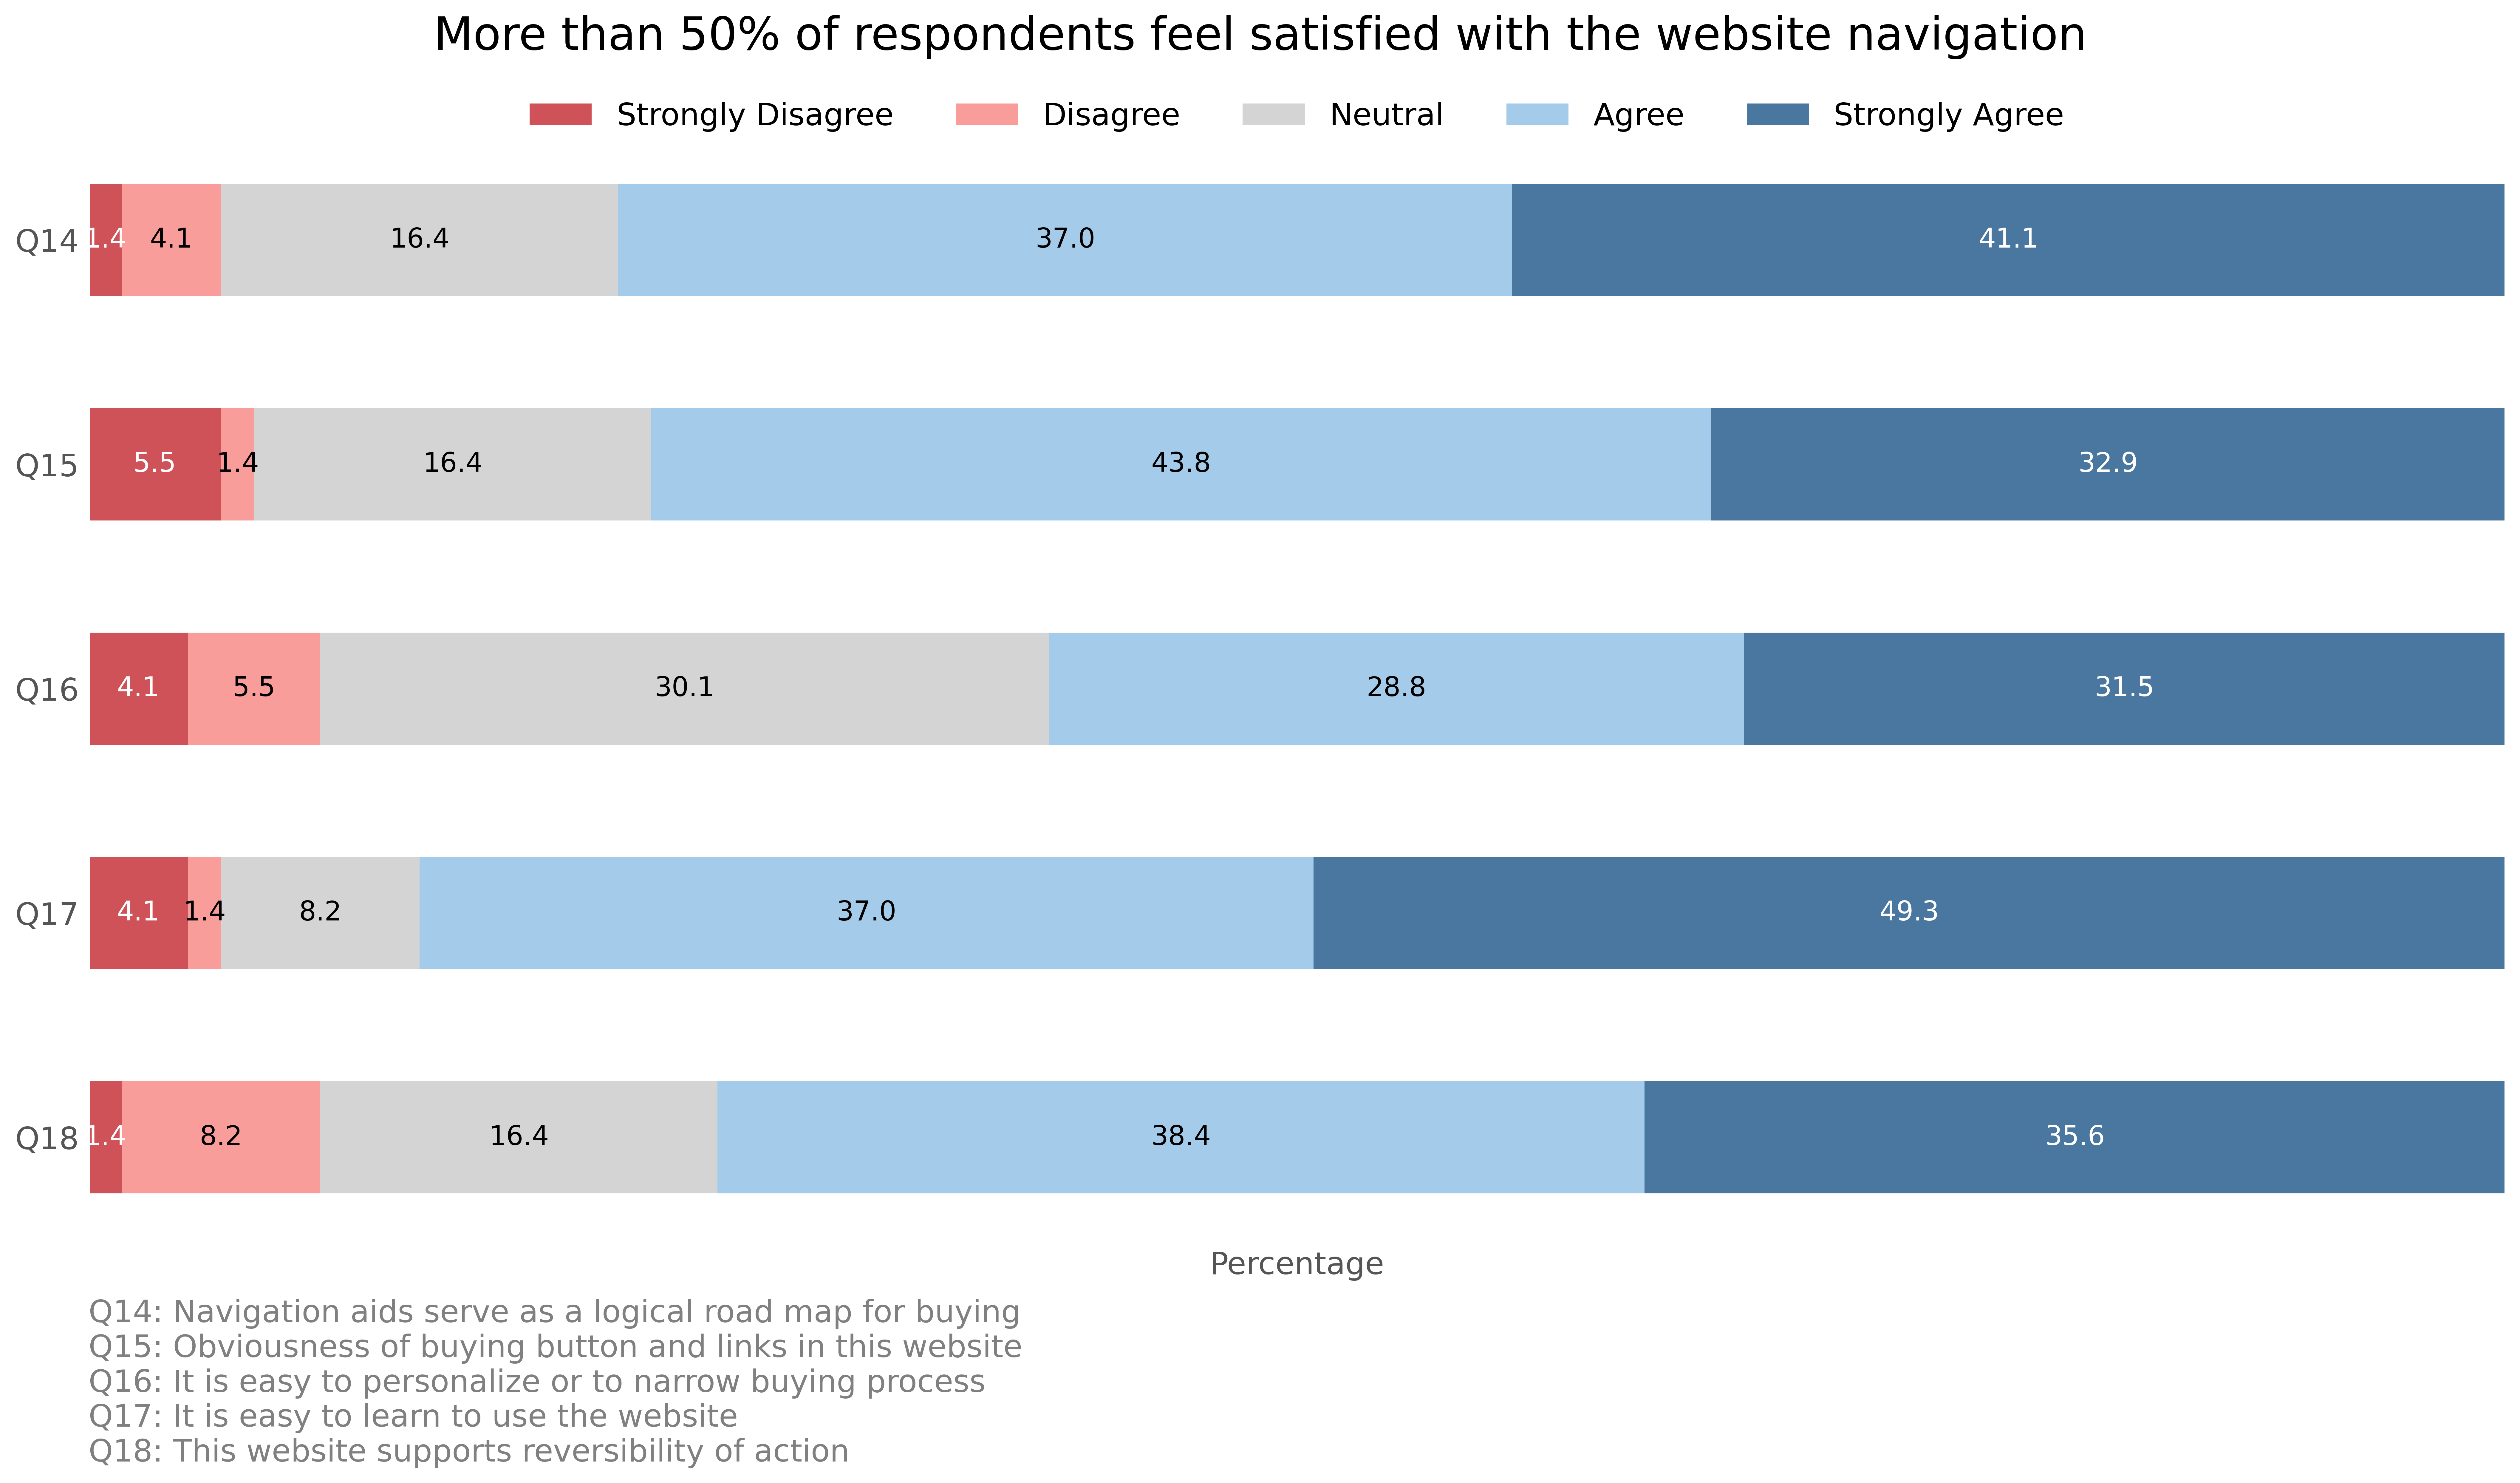

In [58]:
# select specific questions to visualize
selected_questions = percentages.loc['Q18':'Q14', :]

fig, ax = plt.subplots(figsize=(17, len(selected_questions.index) * 2), dpi=500)
colors = ['#ce5258', '#f99d9b', '#d5d4d4', '#a4cbea', '#49779f']

# visualize main plot
selected_questions.plot(kind='barh', stacked=True, color=colors, ax=ax)
# add main title and subtitle
fig.suptitle('More than 50% of respondents feel satisfied with the website navigation', 
             y=0.99, size=22, weight='normal')
ax.set_title('Q14: Navigation aids serve as a logical road map for buying\n' 
             'Q15: Obviousness of buying button and links in this website\n' 
             'Q16: It is easy to personalize or to narrow buying process\n' 
             'Q17: It is easy to learn to use the website\n' 
             'Q18: This website supports reversibility of action', 
             fontsize=15, loc='left', y=-0.2, color='grey')
ax.set_xlabel('Percentage', labelpad=-3, size=15)
ax.set_ylabel(None)
ax.set_xticks([])
ax.set_xlim(0, 100)
ax.set_yticklabels(selected_questions.index, position=(-0.001, 0), size=15)
# add data labels
for i in range(len(selected_questions)):
    cumulative = 0
    for j in range(len(colors)):
        cumulative += selected_questions.iloc[i, j]
        label_color = 'white' if j == 0 or j == 4 else 'black'
        ax.text(cumulative - selected_questions.iloc[i, j]/2, i,
                f"{selected_questions.iloc[i, j]:.1f}",
                ha='center', va='center', color=label_color, size=13)
# setup legend
ax.legend(bbox_to_anchor=(0.5, 1.01), loc='center', ncol=5, facecolor='white', 
          frameon=False, fontsize=15)
ax.yaxis.set_tick_params(which='both', length=0)
ax.grid(None)
# remove background color
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
plt.tight_layout()
plt.show()

**Note**: The website's navigation features are positively rated by over half of the respondents, especially in terms of ease of use and the logical structure provided by navigation aids. However, improvements are needed in areas such as personalization of the buying process and the visibility of buying buttons and links.

#### **3.3.6 Satisfaction**

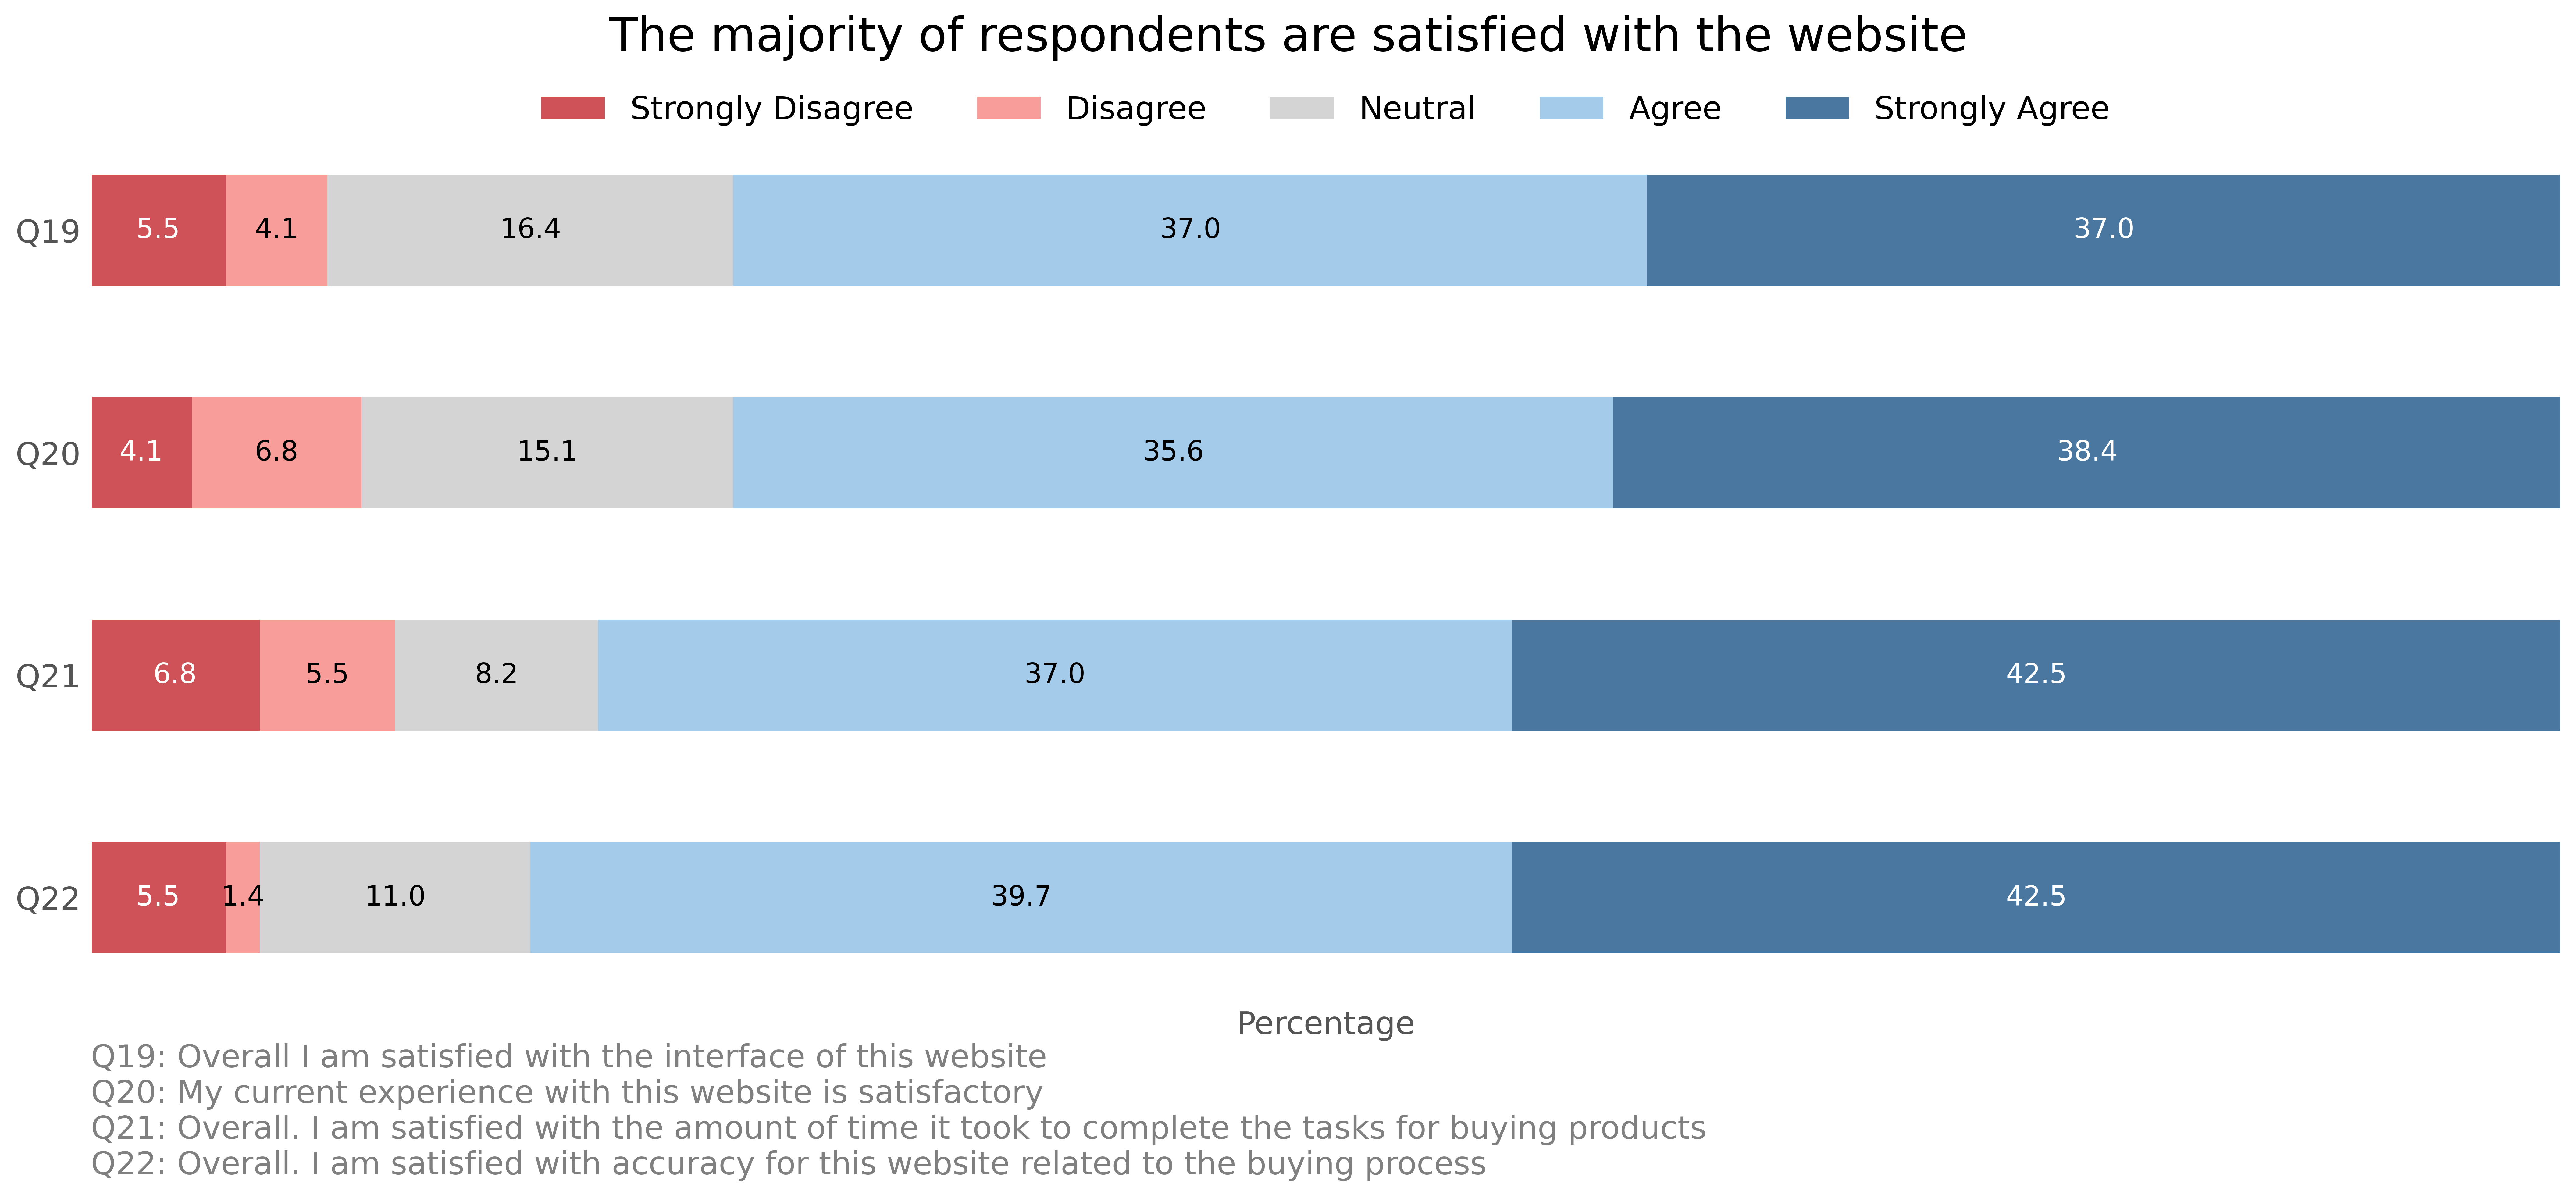

In [65]:
## PERCOBAAN ##

# Select specific questions to visualize
selected_questions = percentages.loc['Q22':'Q19', :]

fig, ax = plt.subplots(figsize=(17, len(selected_questions.index) * 2), dpi=500)
colors = ['#ce5258', '#f99d9b', '#d5d4d4', '#a4cbea', '#49779f']

# visualize main plot
selected_questions.plot(kind='barh', stacked=True, color=colors, ax=ax)

# add main title and subtitle
fig.suptitle('The majority of respondents are satisfied with the website', size=22, weight='normal')
ax.set_title('Q19: Overall I am satisfied with the interface of this website\n' 
             'Q20: My current experience with this website is satisfactory\n' 
             'Q21: Overall. I am satisfied with the amount of time it took to complete the tasks for buying products\n' 
             'Q22: Overall. I am satisfied with accuracy for this website related to the buying process', 
             fontsize=15, loc='left', y=-0.2, x=0.0001, color='grey', style='normal')
ax.set_xlabel('Percentage', labelpad=-3, size=15)
ax.set_ylabel(None)
ax.set_xticks([])
ax.set_xlim(0, 100)
ax.set_yticklabels(selected_questions.index, position=(-0.001, 0), size=15)

# add data labels
for i in range(len(selected_questions)):
    cumulative = 0
    for j in range(len(colors)):
        cumulative += selected_questions.iloc[i, j]
        label_color = 'white' if j == 0 or j == 4 else 'black'
        ax.text(cumulative - selected_questions.iloc[i, j]/2, i,
                f"{selected_questions.iloc[i, j]:.1f}",
                ha='center', va='center', color=label_color, size=13)
        
# setup legend
ax.legend(bbox_to_anchor=(0.5, 1.01), loc='center', ncol=5, facecolor='white', 
          frameon=False, fontsize=15)
ax.yaxis.set_tick_params(which='both', length=0)
ax.grid(None)

# remove background color
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
plt.tight_layout()
plt.show()

Most users are satisfied with the website’s interface and their overall experience, as indicated by high agreement levels for Q19 and Q20. However, there is a notable neutral response regarding the time taken to complete tasks and the accuracy of the buying process, suggesting areas for potential improvement.

#### **3.3.7 Trust**

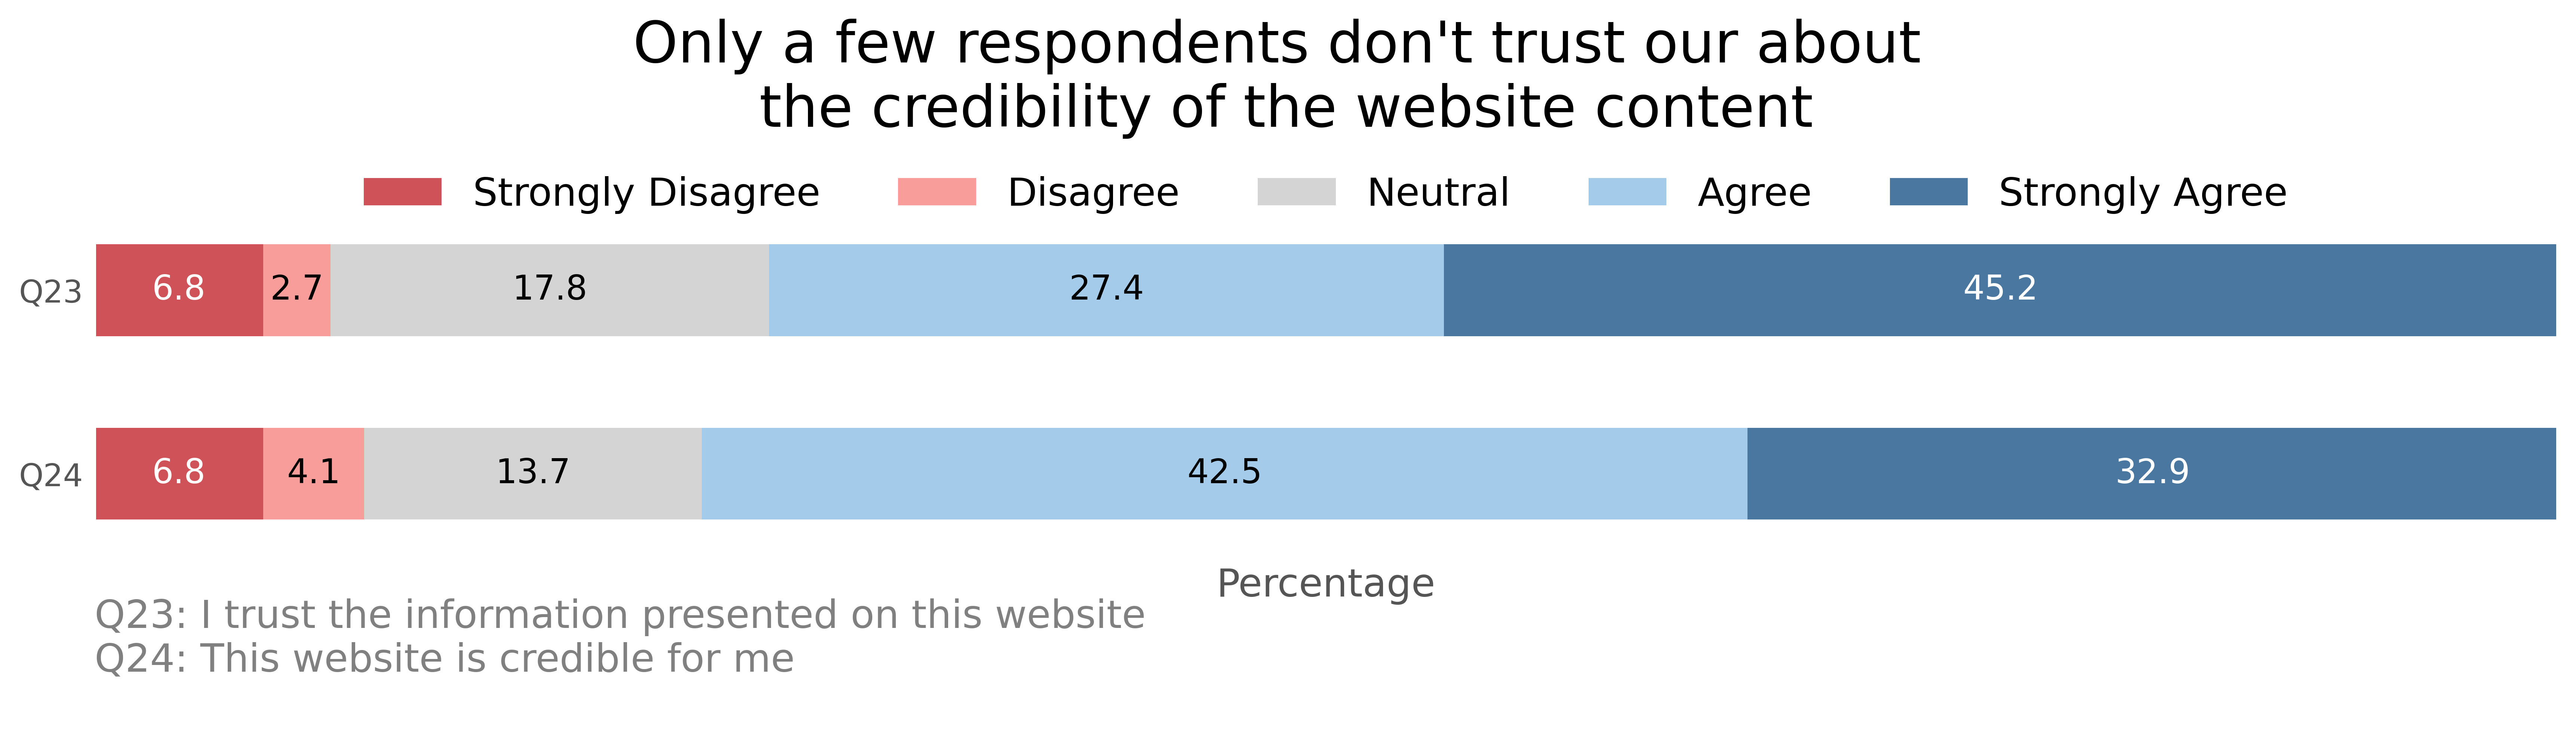

In [70]:
# select specific questions to visualize
selected_questions = percentages.loc['Q24':'Q23', :]

fig, ax = plt.subplots(figsize=(17, len(selected_questions.index) * 1.3), dpi=500)
colors = ['#ce5258', '#f99d9b', '#d5d4d4', '#a4cbea', '#49779f']

# visualize main plot
selected_questions.plot(kind='barh', stacked=True, color=colors, ax=ax)
# add main title and subtitle
fig.suptitle('Only a few respondents don\'t trust our about \nthe credibility of the website content', 
             y=1.25, size=22, weight='normal')
ax.set_title('Q23: I trust the information presented on this website\n' 
             'Q24: This website is credible for me\n', 
             fontsize=15, loc='left', y=-0.45, color='grey', style='normal')
ax.set_xlabel('Percentage', labelpad=-3, size=15)
ax.set_ylabel(None)
ax.set_xticks([])
ax.set_xlim(0, 100)
ax.set_yticklabels(selected_questions.index, position=(-0.001, 0), size=12)
# add data labels
for i in range(len(selected_questions)):
    cumulative = 0
    for j in range(len(colors)):
        cumulative += selected_questions.iloc[i, j]
        label_color = 'white' if j == 0 or j == 4 else 'black'
        ax.text(cumulative - selected_questions.iloc[i, j]/2, i,
                f"{selected_questions.iloc[i, j]:.1f}",
                ha='center', va='center', color=label_color, size=13)
# setup legend
ax.legend(bbox_to_anchor=(0.5, 1.01), loc='center', ncol=5, facecolor='white', 
          frameon=False, fontsize=15)
ax.yaxis.set_tick_params(which='both', length=0)
ax.grid(None)
# remove background color
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
plt.show()

**Note**: The majority of users trust the information presented on the website, with 45.2% agreeing or strongly agreeing. However, while 32.9% find the website credible, a significant 42.5% remain neutral, indicating an opportunity to enhance the site’s credibility.

#### **3.3.8 Loyalty**

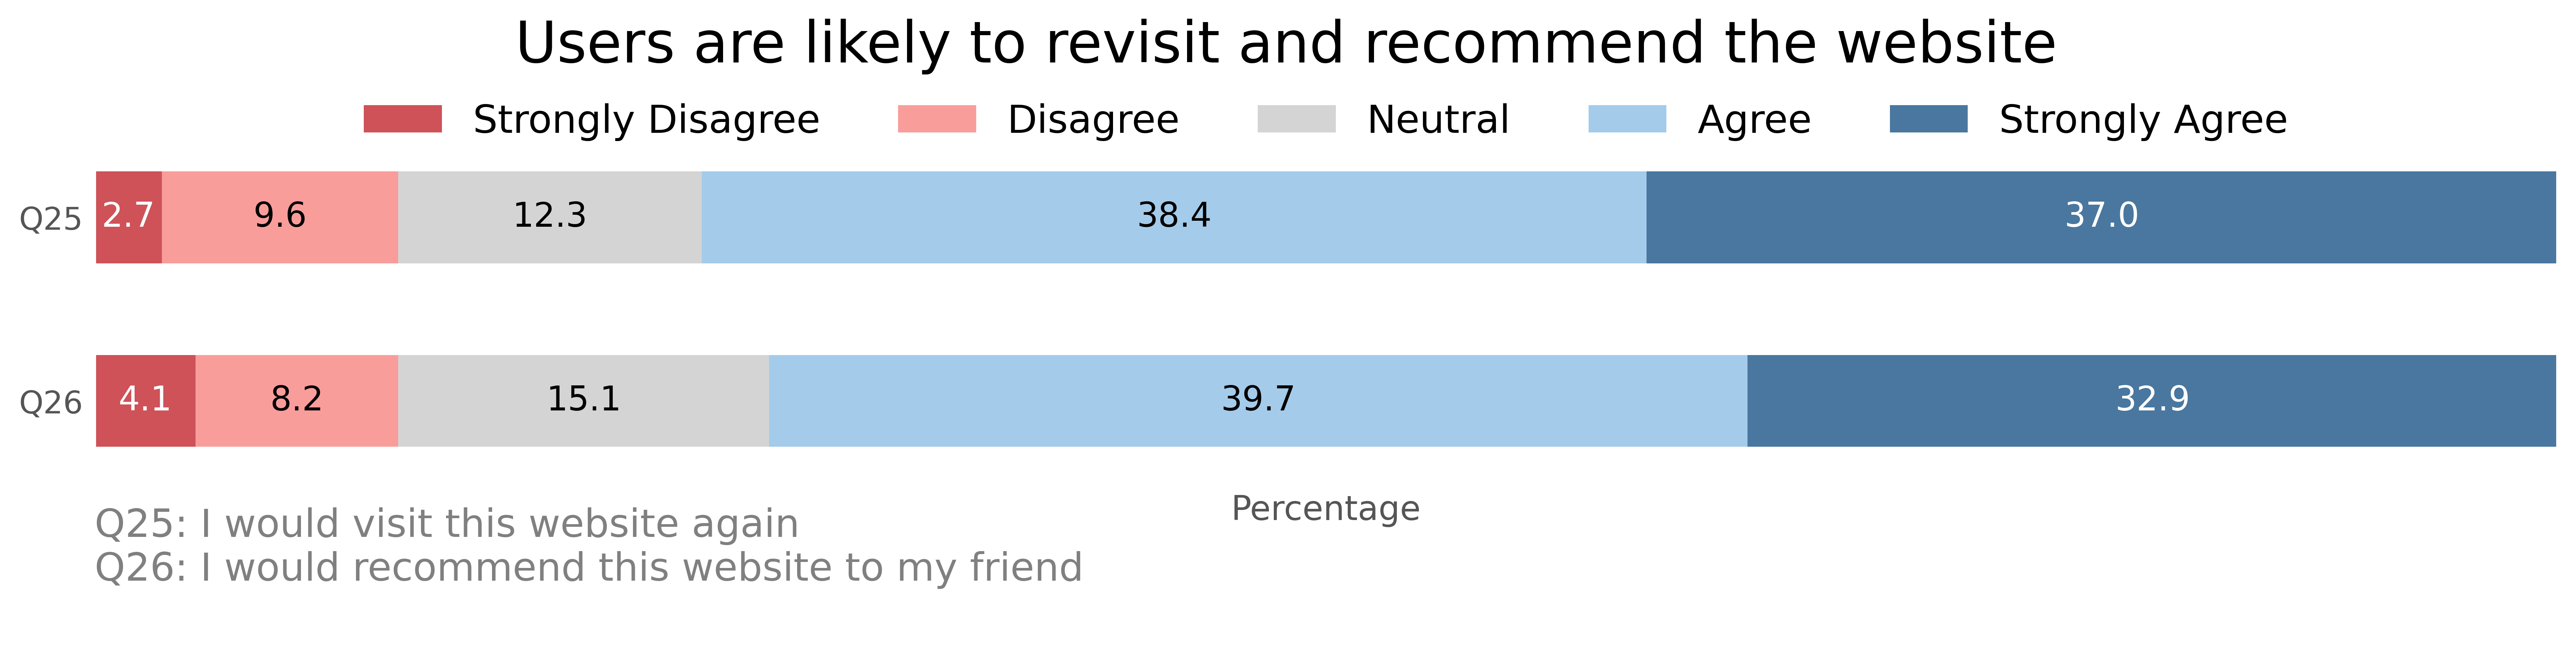

In [72]:
# select specific questions to visualize
selected_questions = percentages.loc['Q26':'Q25', :]

fig, ax = plt.subplots(figsize=(17, len(selected_questions.index) * 1.3), dpi=500)
colors = ['#ce5258', '#f99d9b', '#d5d4d4', '#a4cbea', '#49779f']

# visualize main plot
selected_questions.plot(kind='barh', stacked=True, color=colors, ax=ax)

# add main title and subtitle
fig.suptitle('Users are likely to revisit and recommend the website', 
             y=1.1, size=22, weight='normal')
ax.set_title('Q25: I would visit this website again\n' 
             'Q26: I would recommend this website to my friend\n', 
             fontsize=15, loc='left', y=-0.4, color='grey', style='normal')
ax.set_xlabel('Percentage', labelpad=-3, size=13)
ax.set_ylabel(None)
ax.set_xticks([])
ax.set_xlim(0, 100)
ax.set_yticklabels(selected_questions.index, position=(-0.001, 0), size=12)
# add data labels
for i in range(len(selected_questions)):
    cumulative = 0
    for j in range(len(colors)):
        cumulative += selected_questions.iloc[i, j]
        label_color = 'white' if j == 0 or j == 4 else 'black'
        ax.text(cumulative - selected_questions.iloc[i, j]/2, i,
                f"{selected_questions.iloc[i, j]:.1f}",
                ha='center', va='center', color=label_color, size=13)
# setup legend
ax.legend(bbox_to_anchor=(0.5, 1.01), loc='center', ncol=5, facecolor='white', 
          frameon=False, fontsize=15)
ax.yaxis.set_tick_params(which='both', length=0)
ax.grid(None)

# remove background color
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
plt.show()

**Note**: The majority of users are likely to revisit the website, with 37.0% strongly agreeing to do so. Additionally, 32.9% of users would recommend the website to a friend, indicating strong user loyalty and positive word-of-mouth potential.

## **3.4 References**
- Faisal, C. M. N., Gonzalez-Rodriguez, M., FernandezLanvin, D., & Andres-Suarez, J. De. (2017). Web Design Attributes in Building User Trust, Satisfaction, and Loyalty for a High Uncertainty Avoidance Culture. *IEEE Transactions on Human-Machine Systems*, 47(6), 847–859. https://doi.org/10.1109/THMS.2016.2620901

<h1 style='color:orange; text-align:center; font-weight:bold'>--END--</h1>

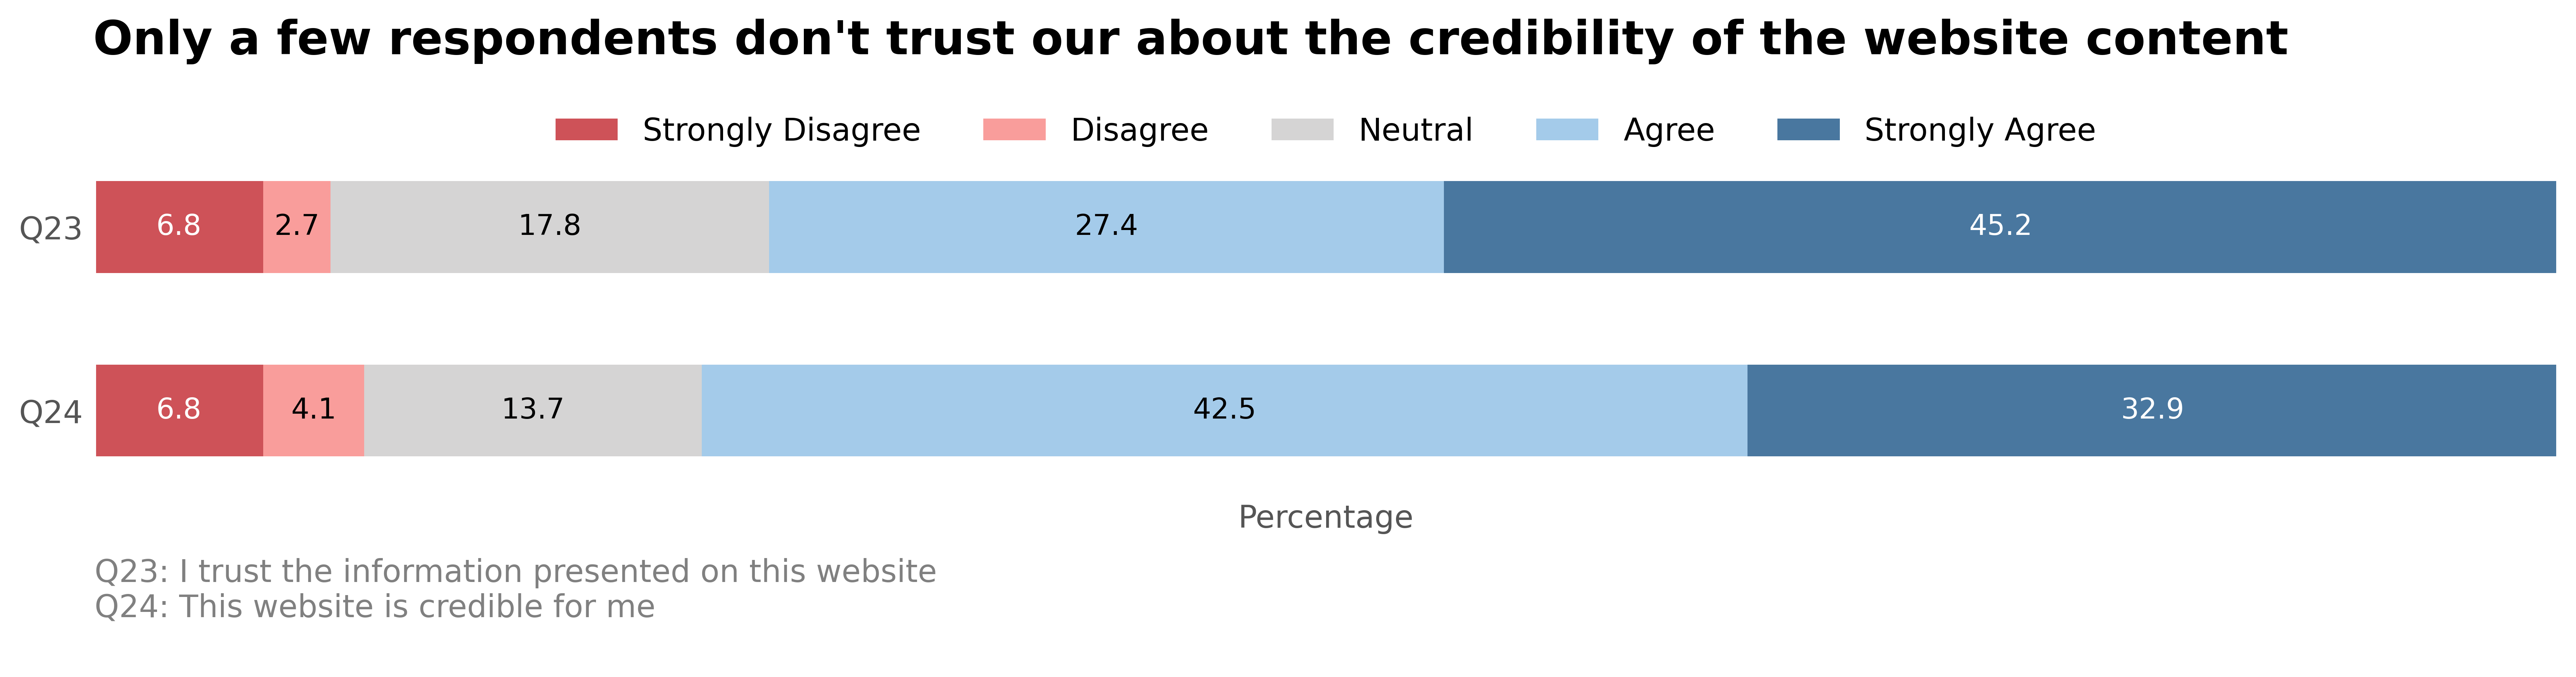

In [31]:
# select specific questions to visualize
selected_questions = percentages.loc['Q24':'Q23', :]

fig, ax = plt.subplots(figsize=(17, len(selected_questions.index) * 1.3), dpi=500)
colors = ['#ce5258', '#f99d9b', '#d5d4d4', '#a4cbea', '#49779f']

# visualize main plot
selected_questions.plot(kind='barh', stacked=True, color=colors, ax=ax)
# add main title and subtitle
fig.suptitle('Only a few respondents don\'t trust our about the credibility of the website content', 
             y=1.12, size=18, x=0.470, weight='bold')
ax.set_title('Q23: I trust the information presented on this website\n' 
             'Q24: This website is credible for me\n', 
             fontsize=12, loc='left', y=-0.45, color='grey', style='normal')
ax.set_xlabel('Percentage', labelpad=-3)
ax.set_ylabel(None)
ax.set_xticks([])
ax.set_xlim(0, 100)
ax.set_yticklabels(selected_questions.index, position=(-0.001, 0), size=12)
# add data labels
for i in range(len(selected_questions)):
    cumulative = 0
    for j in range(len(colors)):
        cumulative += selected_questions.iloc[i, j]
        label_color = 'white' if j == 0 or j == 4 else 'black'
        ax.text(cumulative - selected_questions.iloc[i, j]/2, i,
                f"{selected_questions.iloc[i, j]:.1f}",
                ha='center', va='center', color=label_color, size=11)
# setup legend
ax.legend(bbox_to_anchor=(0.5, 1.01), loc='center', ncol=5, facecolor='white', 
          frameon=False, fontsize=12)
ax.yaxis.set_tick_params(which='both', length=0)
ax.grid(None)
# remove background color
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
plt.show()

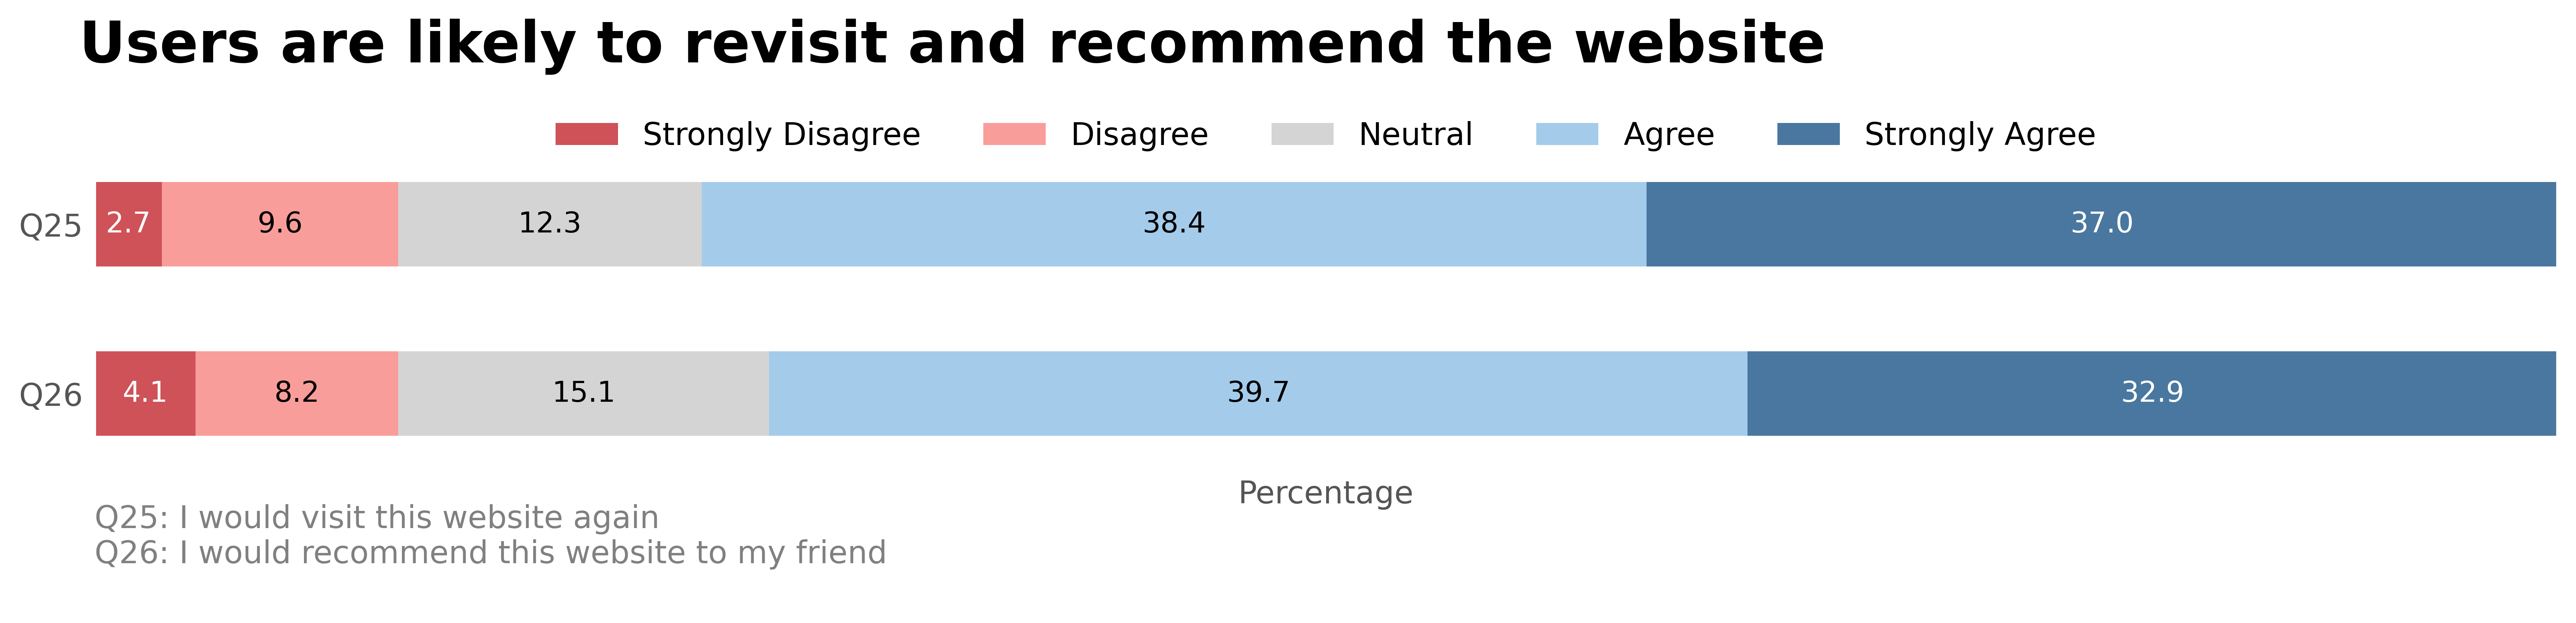

In [32]:
# select specific questions to visualize
selected_questions = percentages.loc['Q26':'Q25', :]

fig, ax = plt.subplots(figsize=(17, len(selected_questions.index) * 1.2), dpi=500)
colors = ['#ce5258', '#f99d9b', '#d5d4d4', '#a4cbea', '#49779f']

# visualize main plot
selected_questions.plot(kind='barh', stacked=True, color=colors, ax=ax)

# add main title and subtitle
fig.suptitle('Users are likely to revisit and recommend the website', 
             y=1.15, size=22, x=0.395, weight='bold')
ax.set_title('Q25: I would visit this website again\n' 
             'Q26: I would recommend this website to my friend\n', 
             fontsize=12, loc='left', y=-0.4, color='grey', style='normal')
ax.set_xlabel('Percentage', labelpad=-3)
ax.set_ylabel(None)
ax.set_xticks([])
ax.set_xlim(0, 100)
ax.set_yticklabels(selected_questions.index, position=(-0.001, 0), size=12)
# add data labels
for i in range(len(selected_questions)):
    cumulative = 0
    for j in range(len(colors)):
        cumulative += selected_questions.iloc[i, j]
        label_color = 'white' if j == 0 or j == 4 else 'black'
        ax.text(cumulative - selected_questions.iloc[i, j]/2, i,
                f"{selected_questions.iloc[i, j]:.1f}",
                ha='center', va='center', color=label_color, size=11)
# setup legend
ax.legend(bbox_to_anchor=(0.5, 1.01), loc='center', ncol=5, facecolor='white', 
          frameon=False, fontsize=12)
ax.yaxis.set_tick_params(which='both', length=0)
ax.grid(None)

# remove background color
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
plt.show()

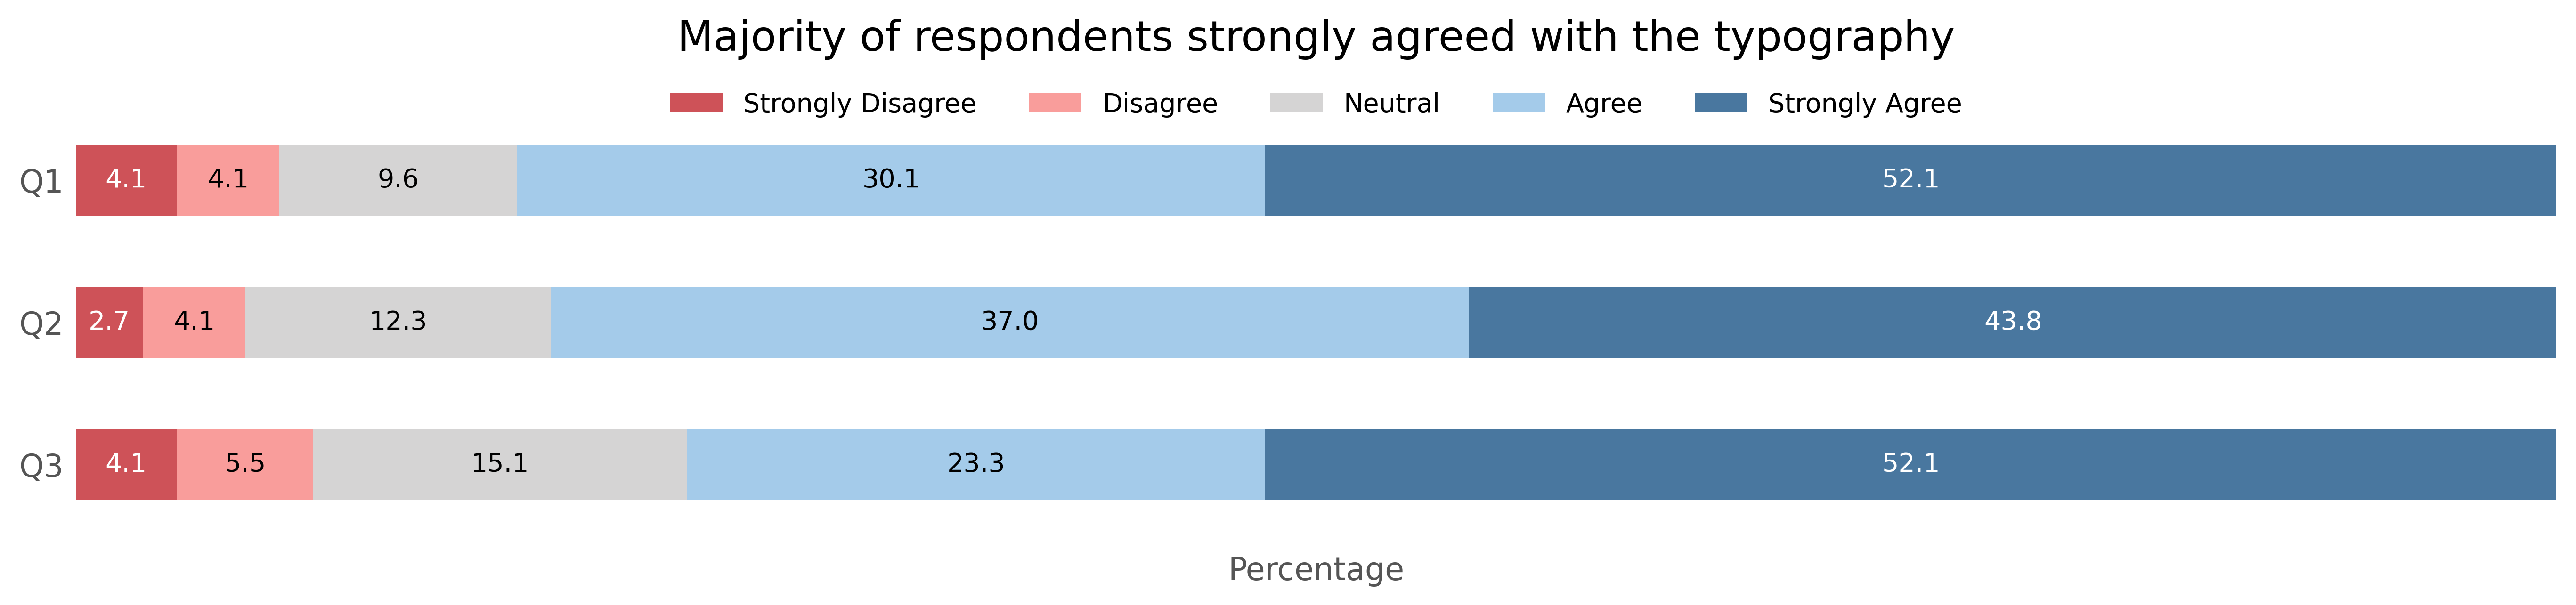

In [33]:
# select specific questions to visualize
selected_questions = percentages.loc['Q3':'Q1', :]

fig, ax = plt.subplots(figsize=(17, len(selected_questions.index) * 1), dpi=400)
colors = ['#ce5258', '#f99d9b', '#d5d4d4', '#a4cbea', '#49779f']

# visualize data
selected_questions.plot(kind='barh', stacked=True, color=colors, ax=ax)
ax.set_title('Majority of respondents strongly agreed with the typography',
              y=1.1, loc='center', size=16)
ax.set_xlabel('Percentage')
ax.set_ylabel(None)
ax.set_xticks([])
ax.set_xlim(0, 100)                                                         # keep limits for percentage scale
ax.set_yticklabels(selected_questions.index, position=(-0.001, 0), size=12) # move y-ticks slightly to the left

# add data labels
for i in range(len(selected_questions)):
    cumulative = 0
    for j in range(len(colors)):
        cumulative += selected_questions.iloc[i, j]
         # change color for Strongly Disagree and Strongly Agree
        label_color = 'white' if j == 0 or j == 4 else 'black' 
        ax.text(cumulative - selected_questions.iloc[i, j]/2, i,
                f"{selected_questions.iloc[i, j]:.1f}",
                ha='center', va='center', color=label_color, size=10)

ax.legend(bbox_to_anchor=(0.5, 1.01), loc='center', ncol=5, facecolor='white', 
          frameon=False, fontsize=10)
ax.yaxis.set_tick_params(which='both', length=0)
ax.grid(None)

# remove background color
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
plt.show()
